<a href="https://colab.research.google.com/github/TriBot2o/AI_And_ML_Year3/blob/main/2408947_RujanMaharjan_Code_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Part A: Designing and Analyzing Convolutional Neural Networks from Scratch

## Necessary Imports

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
import numpy as np
from tensorflow.keras.models import load_model
import time
from keras import optimizers


## Unzipping the dataset

In [ ]:
# No need to run this cell again as it unzips the dataset directly into the Google Drive, the unzipped files will persist across sessions and runtime changes.
# unless the dataset is deleted from the drive

# The place where the zip dataset is
#zipped_file_path = '/content/drive/MyDrive/AI ML/Data/Pest Dataset.zip'

# The place where the dataset will be unziped
destination_path = '/content/drive/MyDrive/AIML/Assignment/Dataset'

# Unzip the file
#!unzip "{zipped_file_path}" -d "{destination_path}"

## Data Understanding, Analysis, Visualization and Cleaning:

#### Checking total number of images in the dataset

In [ ]:
# The base path to the unzipped dataset
dataset_base_path = os.path.join(destination_path,'working','dataset_publish','balanced_pest_dataset')

image_count = 0
# Define common image extensions to look for
image_extensions = ('.jpg', '.jpeg', '.png')

# Walk through the dataset directory
for root, _, files in os.walk(dataset_base_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_count += 1

print(f"Total number of images in the dataset: {image_count}")

Total number of images in the dataset: 34200


#### Checking the distribution of images across different classes

In [ ]:
# Define the paths for train and validation datasets
train_path = os.path.join(dataset_base_path, 'train')
val_path = os.path.join(dataset_base_path, 'val')
test_path = os.path.join(dataset_base_path, 'test')

# Function to get class distribution
def get_class_distribution(base_dir):
    class_counts = {}
    for class_name in os.listdir(base_dir):
        class_dir = os.path.join(base_dir, class_name)
        if os.path.isdir(class_dir):
            count = len([f for f in os.listdir(class_dir) if f.lower().endswith(image_extensions)])
            class_counts[class_name] = count
    return class_counts

# Get distribution for train and validation sets
train_distribution = get_class_distribution(train_path)
val_distribution = get_class_distribution(val_path)
test_distribution = get_class_distribution(test_path)

# Convert to pandas Series for easier plotting
train_df = pd.Series(train_distribution, name='Count').reset_index()
train_df.columns = ['Class', 'Count']
train_df['Set'] = 'Train'

val_df = pd.Series(val_distribution, name='Count').reset_index()
val_df.columns = ['Class', 'Count']
val_df['Set'] = 'Validation'

test_df = pd.Series(test_distribution, name='Count').reset_index()
test_df.columns = ['Class', 'Count']
test_df['Set'] = 'Test'

# Combine for plotting
combined_df = pd.concat([train_df, val_df,test_df])

print("Training Set Distribution:")
print(train_df)
print("\nValidation Set Distribution:")
print(val_df)
print("\nTest Set Distribution:")
print(test_df)


Training Set Distribution:
                      Class  Count    Set
0             Adristyrannus   1500  Train
1                    Aphids   1500  Train
2                    Beetle   1500  Train
3                      Bugs   1500  Train
4            Cabbage Looper   1500  Train
5              Cicadellidae   1500  Train
6                   Cutworm   1500  Train
7                    Earwig   1500  Train
8              FieldCricket   1500  Train
9               Grasshopper   1500  Train
10  Mediterranean fruit fly   1500  Train
11                    Mites   1500  Train
12                RedSpider   1500  Train
13                Riptortus   1500  Train
14                     Slug   1500  Train
15                    Snail   1500  Train
16                   Thrips   1500  Train
17                   Weevil   1500  Train
18                 Whitefly   1500  Train

Validation Set Distribution:
                      Class  Count         Set
0             Adristyrannus    150  Validation
1        

#### Visualizing the distribution of images accross different classes in train, test and val sets


##### Training set

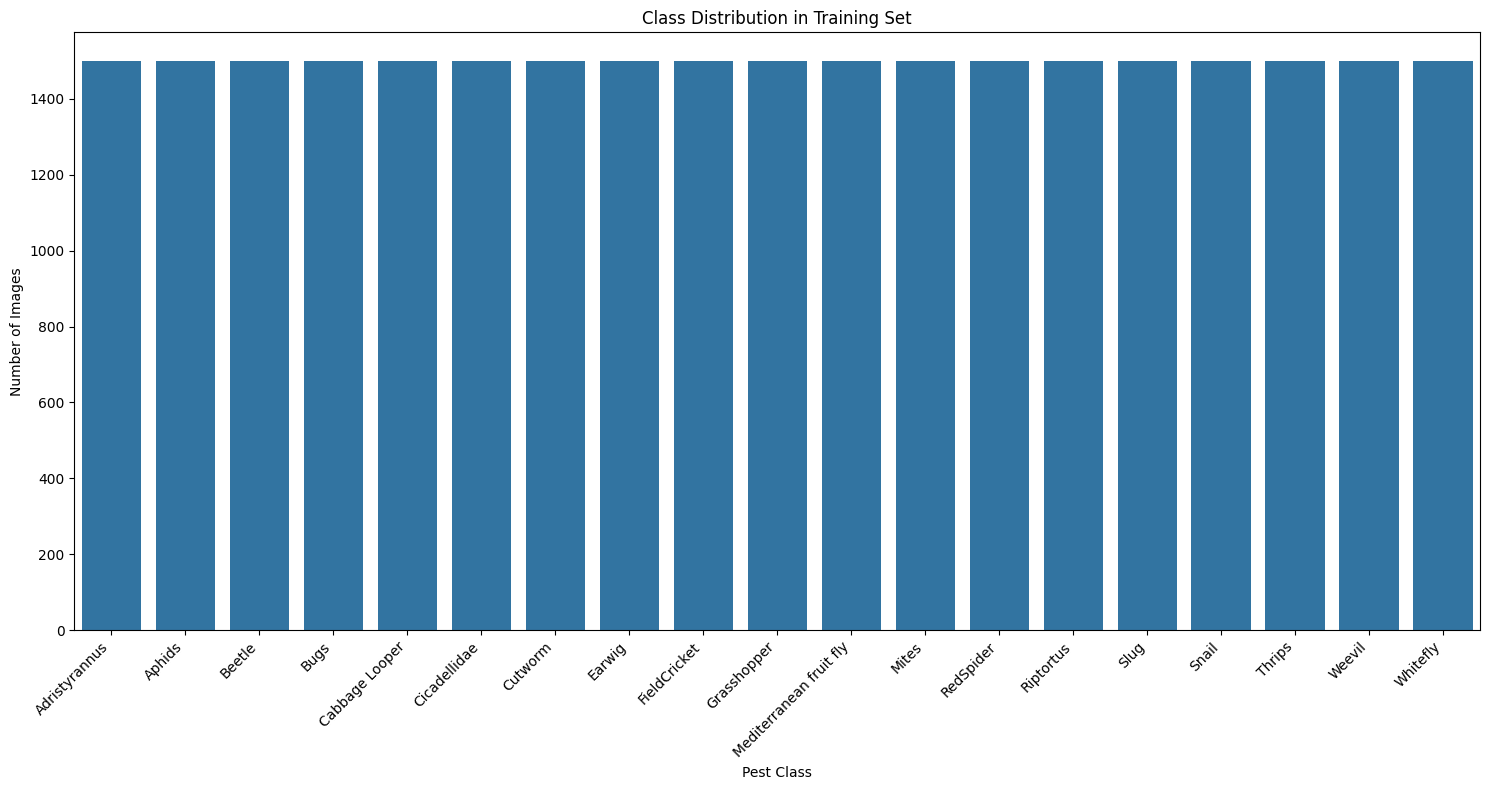

In [ ]:
plt.figure(figsize=(15, 8))
sns.barplot(x='Class', y='Count', data=train_df)
plt.title('Class Distribution in Training Set')
plt.xlabel('Pest Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Validation set

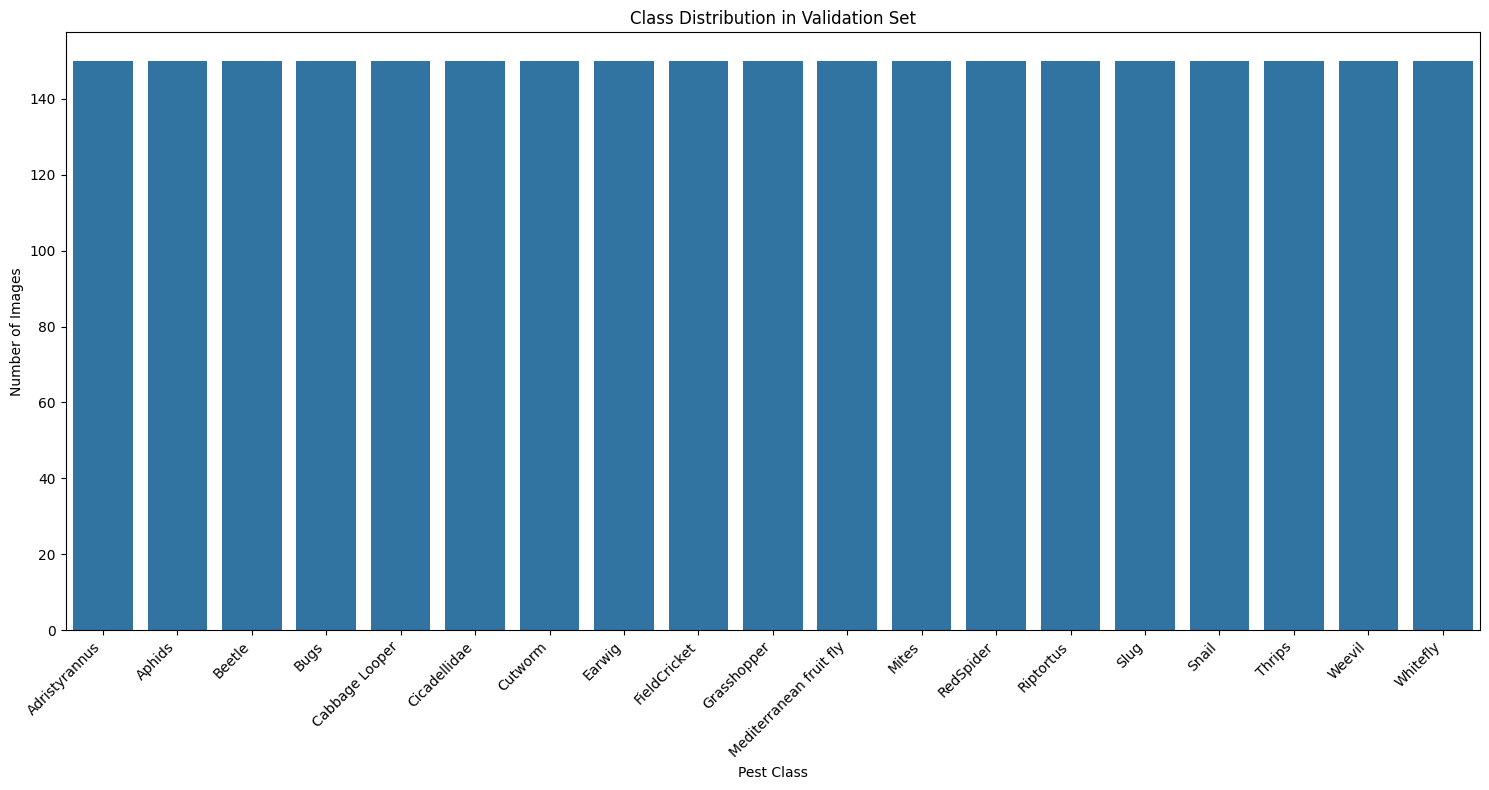

In [ ]:
plt.figure(figsize=(15, 8))
sns.barplot(x='Class', y='Count', data=val_df)
plt.title('Class Distribution in Validation Set')
plt.xlabel('Pest Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Test set

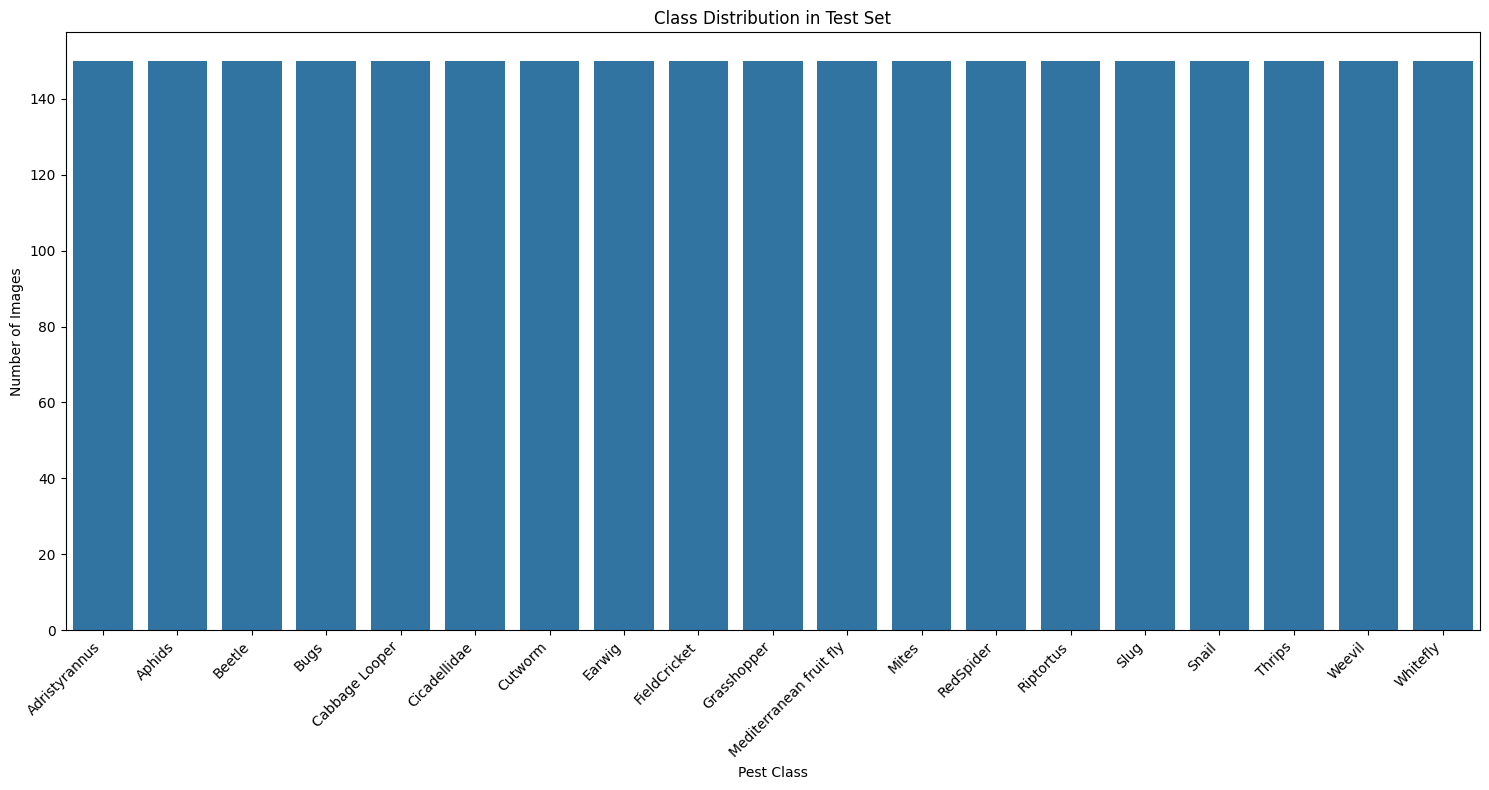

In [ ]:
plt.figure(figsize=(15, 8))
sns.barplot(x='Class', y='Count', data=test_df)
plt.title('Class Distribution in Test Set')
plt.xlabel('Pest Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Visualizing the distribution accross train, val and test sets

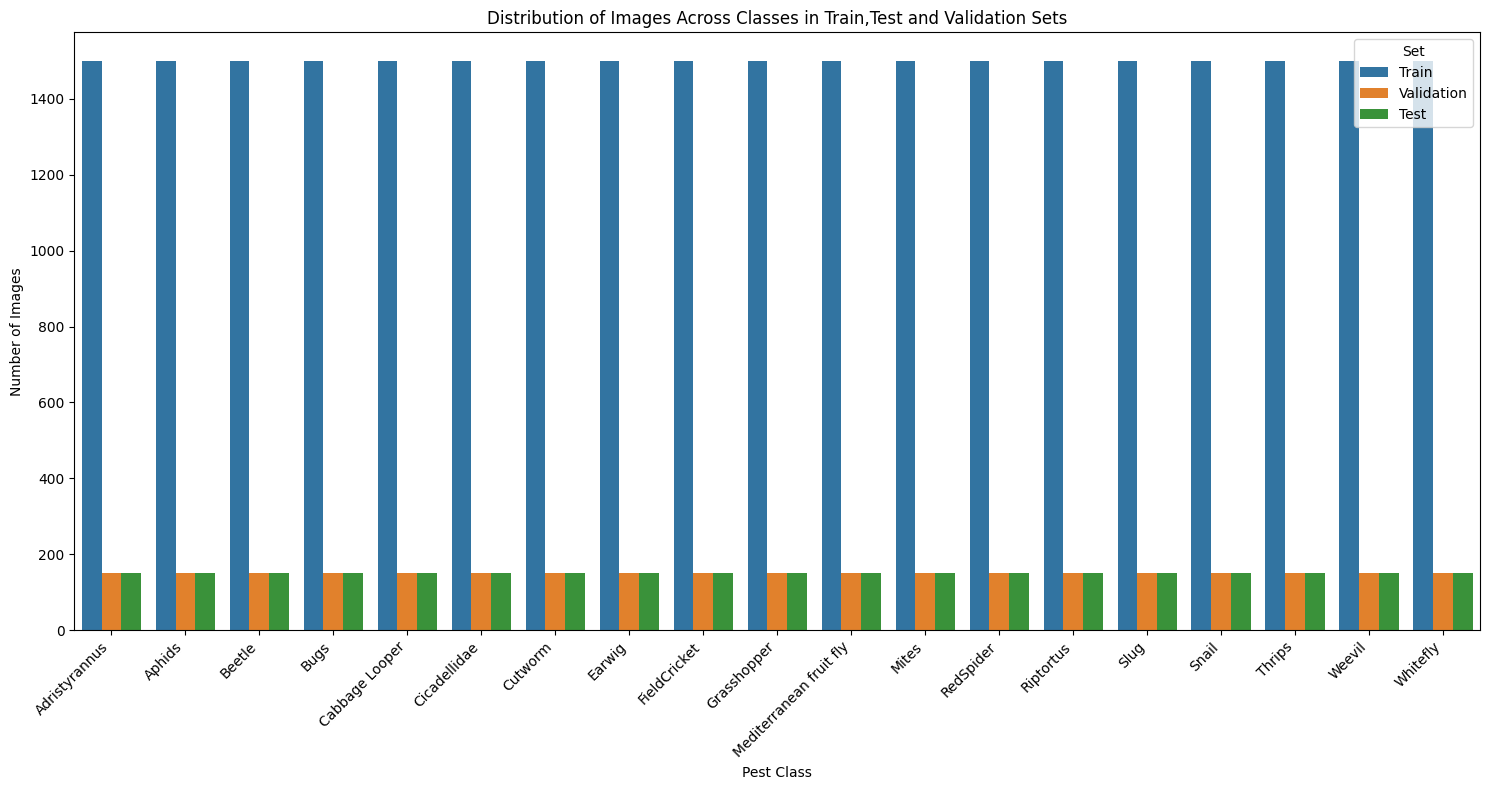

In [ ]:
plt.figure(figsize=(15, 8))
sns.barplot(x='Class', y='Count', hue='Set', data=combined_df)
plt.title('Distribution of Images Across Classes in Train,Test and Validation Sets')
plt.xlabel('Pest Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The dataset is split into training, validation, and test sets with a ratio of 10:1:1 for each class. Specifically, every class has 1500 images in the training set and 150 images in the validation and test sets.
This type of split, where a larger portion of the data 91% for training set and 9% for validation set is a common practice in machine learning.

Justification :
* This split provides the model with enough data to
learn features and patterns effectively preventing underfittting.
* While the val set helps tune hyperparameters using a seperate test set ensures the model isnt optimized for val set resulting in a more robust and objective measure of generalization.
* Maintaining a 10:1:1 ratio for each class across all three sets ensures that the test set, like the training and validation sets, is class-balanced.

#### Visualizing augmented images.

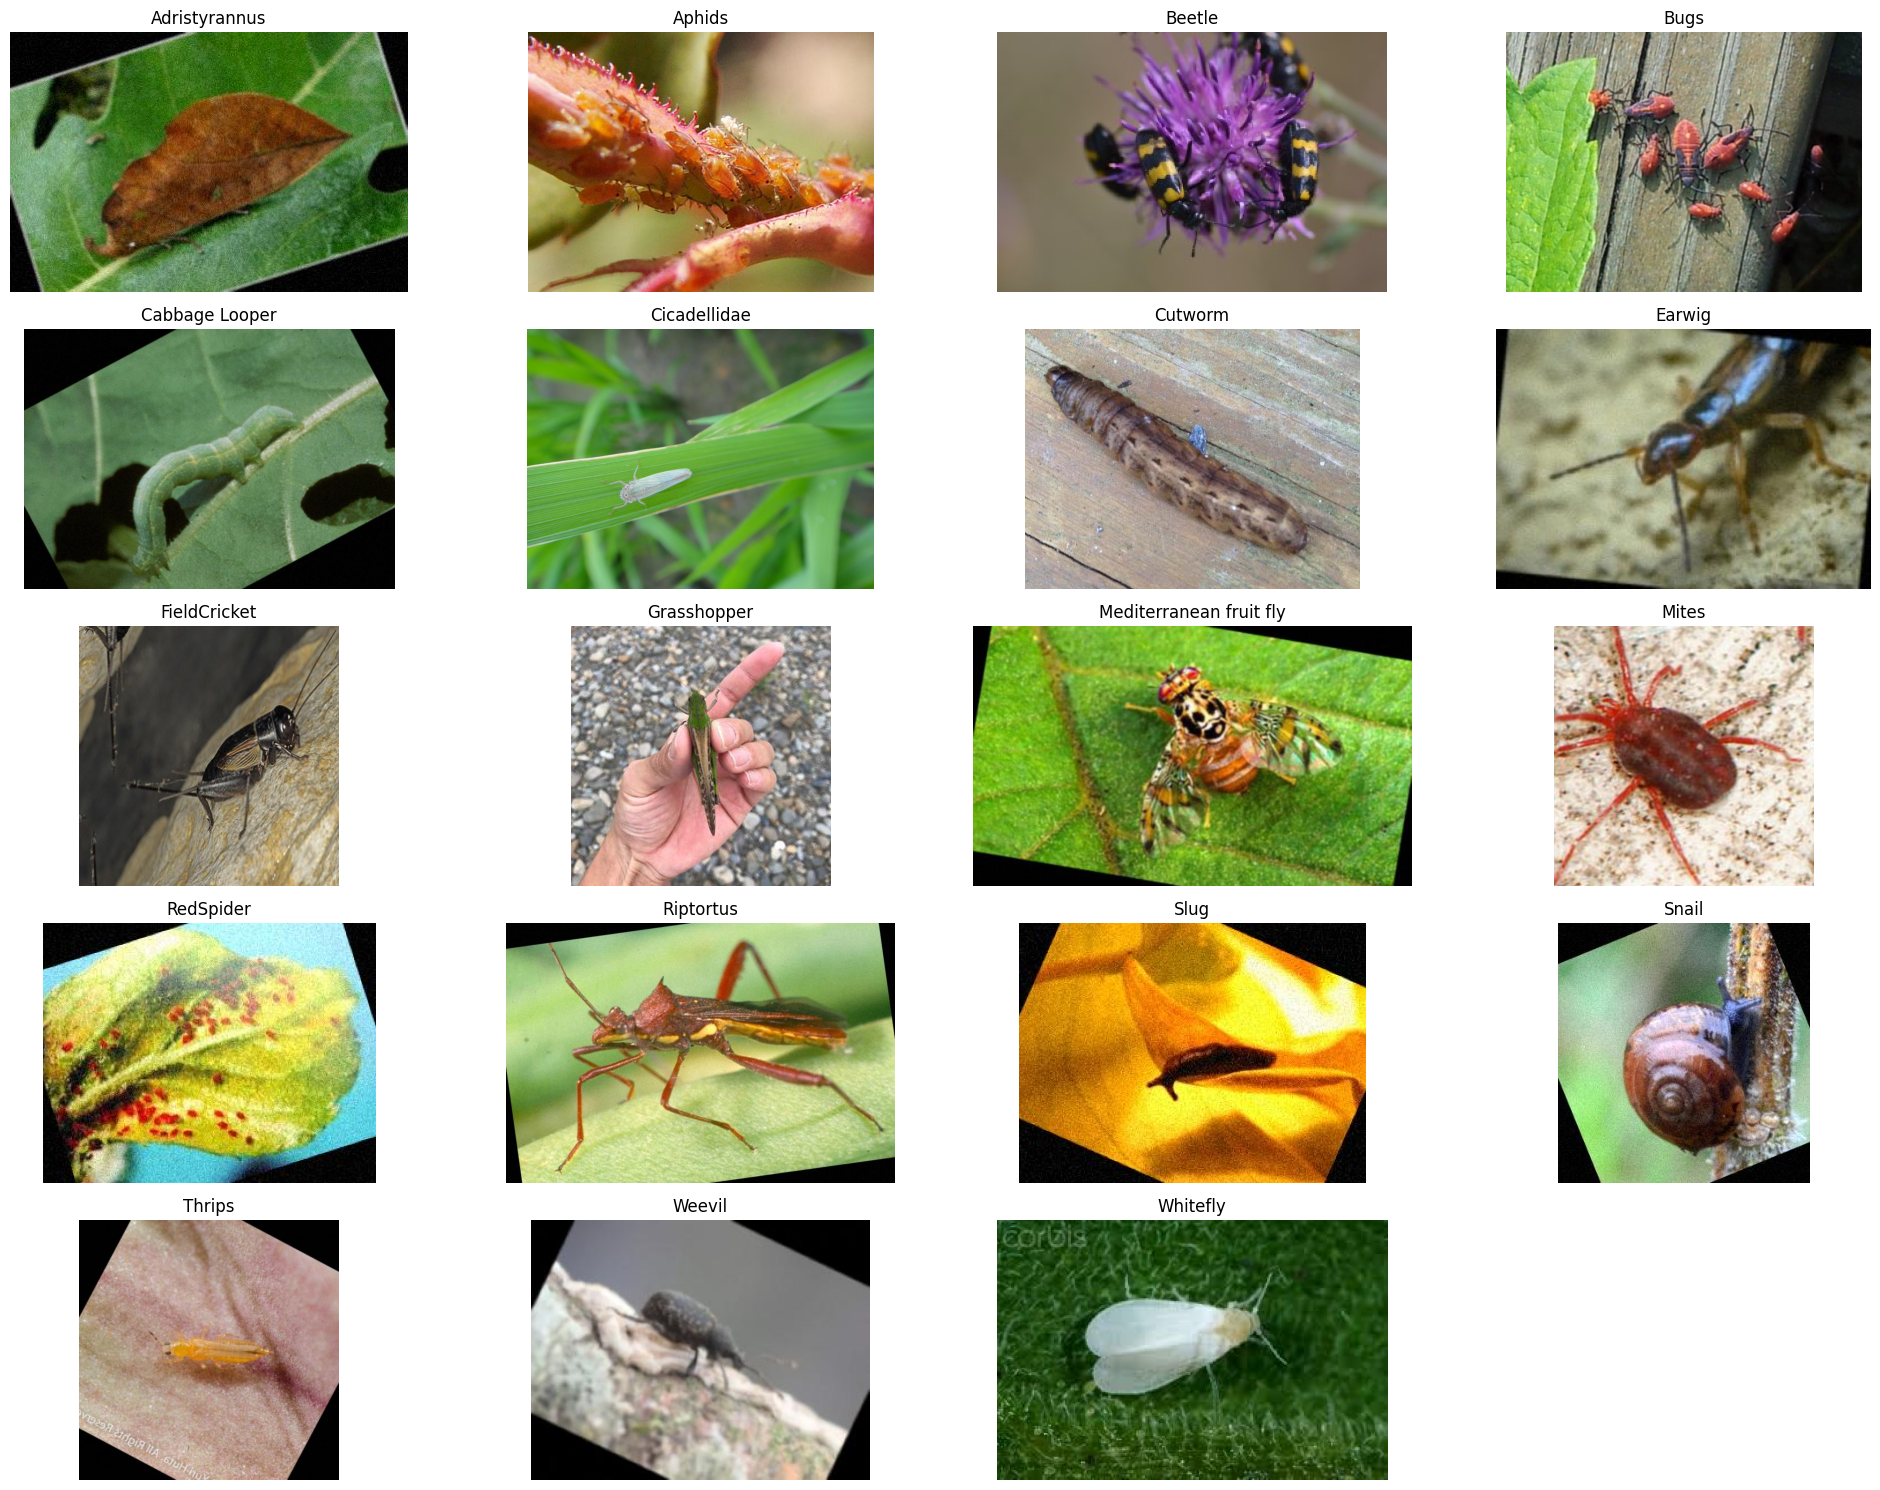

In [ ]:
# Get the list of class names
class_names = sorted(os.listdir(train_path))

plt.figure(figsize=(20, 15))

# Loop through each class and display a sample image
for i, class_name in enumerate(class_names):
    class_dir = os.path.join(train_path, class_name)
    if os.path.isdir(class_dir):
        # Get all image files in the class directory
        image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(image_extensions)]
        if image_files:
            # Pick a random image from the class
            sample_image_name = random.choice(image_files)
            sample_image_path = os.path.join(class_dir, sample_image_name)

            # Load and display the image
            plt.subplot(5, 4, i + 1) # Adjust subplot grid based on number of classes
            img = mpimg.imread(sample_image_path)
            plt.imshow(img)
            plt.title(class_name, fontsize=12)
            plt.axis('off')

plt.tight_layout()
plt.show()

#### Data Generator

In [ ]:
INPUT_SHAPE = (64, 64, 3) # (height, width, channels)
NUM_CLASSES = len(class_names) # Dynamically get the number of classes from the discovered class names

print(f"Input image shape: {INPUT_SHAPE}")
print(f"Number of classes: {NUM_CLASSES}")

Input image shape: (64, 64, 3)
Number of classes: 19


In [ ]:
IMG_HEIGHT = INPUT_SHAPE[0]
IMG_WIDTH = INPUT_SHAPE[1]
BATCH_SIZE = 32

print(f"Loading training data from: {train_path}")
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123 # For reproducibility
)

print(f"\nLoading validation data from: {val_path}")
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False, # Typically no need to shuffle validation data
    seed=123 # For reproducibility
)

# Normalize pixel values to [0, 1]
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print(f"\nLoading test data from: {test_path}")
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    shuffle=False, # Test data should not be shuffled
    seed=123 # For reproducibility
)

test_ds = test_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("\nData preparation complete. Datasets are ready for training.")

Loading training data from: /content/drive/MyDrive/AIML/Assignment/Dataset/working/dataset_publish/balanced_pest_dataset/train
Found 28500 files belonging to 19 classes.

Loading validation data from: /content/drive/MyDrive/AIML/Assignment/Dataset/working/dataset_publish/balanced_pest_dataset/val
Found 2850 files belonging to 19 classes.

Loading test data from: /content/drive/MyDrive/AIML/Assignment/Dataset/working/dataset_publish/balanced_pest_dataset/test
Found 2850 files belonging to 19 classes.

Data preparation complete. Datasets are ready for training.


## Design, Train, and Evaluate a Baseline Model:

### Model Architecture:



This model consists of three convolutional blocks. Each block includes a Conv2D layer for feature extraction, followed by a ReLU activation function, and then a MaxPooling2D layer for dimensionality reduction.

In [ ]:
model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=INPUT_SHAPE),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten the output to feed into dense layers
    layers.Flatten(),

    # Three Dense layers (Fully Connected Network)
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output layer for classification
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 19)             │         2,451 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,731 (9.99 MB)

 Trainable params: 2,619,731 (9.99 MB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Define the directory where models will be saved
model_save_dir = '/content/drive/MyDrive/AIML/Models'
os.makedirs(model_save_dir, exist_ok=True)

# ModelCheckpoint callback
model_checkpoint = ModelCheckpoint(
    filepath=os.path.join(model_save_dir, 'best_baseline_model.keras'),
    monitor='val_loss', # Monitor validation loss
    save_best_only=True, # Save only the best model found so far
    mode='min', # 'min' because we want to minimize validation loss
    verbose=1
)

# Early stop callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

In [ ]:
print("Training Baseline Model...")
start_time_baseline = time.time()
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint]
)
end_time_baseline = time.time()
training_time_baseline = end_time_baseline - start_time_baseline
print(f"Baseline Model Training Time: {training_time_baseline:.2f} seconds")

Training Baseline Model...
Epoch 1/20
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1849 - loss: 2.5773
Epoch 1: val_loss improved from None to 2.11988, saving model to /content/drive/MyDrive/AIML/Models/best_baseline_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AIML/Models/best_baseline_model.keras
891/891 ━━━━━━━━━━━━━━━━━━━━ 1772s 2s/step - accuracy: 0.2622 - loss: 2.3307 - val_accuracy: 0.3382 - val_loss: 2.1199
Epoch 2/20
885/891 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3755 - loss: 1.9493
Epoch 2: val_loss improved from 2.11988 to 1.92758, saving model to /content/drive/MyDrive/AIML/Models/best_baseline_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AIML/Models/best_baseline_model.keras
891/891 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4089 - loss: 1.8416 - val_accuracy: 0.3891 - val_loss: 1.9276
Epoch 3/20
886/891 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4936 - loss: 1.5772
Epoch 3: val_loss did not improve

#### Plotting training and validation loss

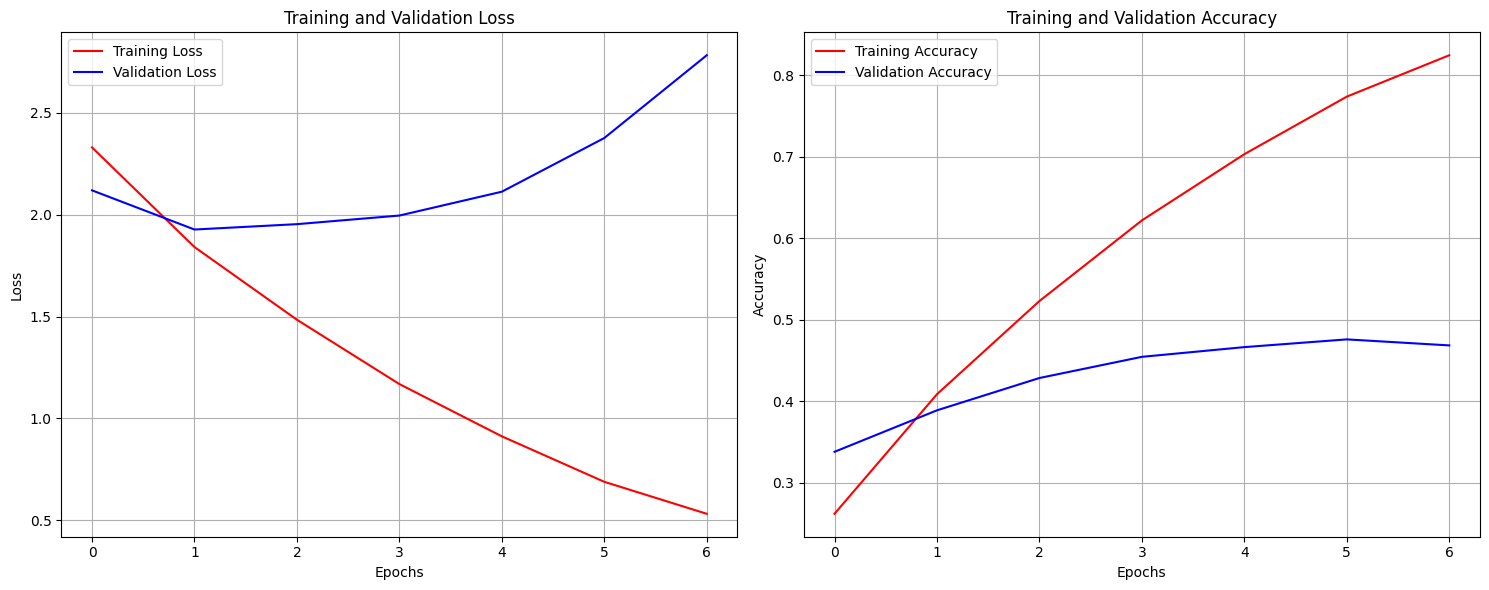

In [ ]:
# Get training and validation loss from history
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get training and validation accuracy from history
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs = range(len(loss))

plt.figure(figsize=(15, 6))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy, 'r', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Model Evaluation

In [ ]:
# Load the saved best model
loaded_model = load_model(os.path.join(model_save_dir, 'best_baseline_model.keras'))

# Get true labels from the validation dataset
val_labels = []
for _, labels in val_ds:
    val_labels.extend(np.argmax(labels.numpy(), axis=1))
val_labels = np.array(val_labels)

# Get predictions from the loaded model
val_predictions = model.predict(val_ds)
predicted_classes = np.argmax(val_predictions, axis=1)

# Ensure class names are available if needed for classification report
# If class_names are not globally available, you might need to re-extract them
# from val_ds.class_names or os.listdir(val_path)
if 'class_names' not in globals():
    # This block re-extracts class_names if the previous cell defining it was not run in this session
    val_path = '/content/drive/MyDrive/AIML/Assignment/Dataset/working/dataset_publish/balanced_pest_dataset/val'
    class_names = sorted(os.listdir(val_path))

# Generate a classification report
print("Classification Report:")
print(classification_report(val_labels, predicted_classes, target_names=class_names))

90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
Classification Report:
                         precision    recall  f1-score   support

          Adristyrannus       0.35      0.34      0.35       150
                 Aphids       0.24      0.20      0.22       150
                 Beetle       0.36      0.51      0.43       150
                   Bugs       0.47      0.17      0.25       150
         Cabbage Looper       0.73      0.51      0.60       150
           Cicadellidae       0.46      0.39      0.42       150
                Cutworm       0.22      0.42      0.29       150
                 Earwig       0.27      0.19      0.22       150
           FieldCricket       0.37      0.49      0.42       150
            Grasshopper       0.22      0.15      0.18       150
Mediterranean fruit fly       0.77      0.57      0.65       150
                  Mites       0.50      0.59      0.54       150
              RedSpider       0.62      0.29      0.40       150
              Riptortus   

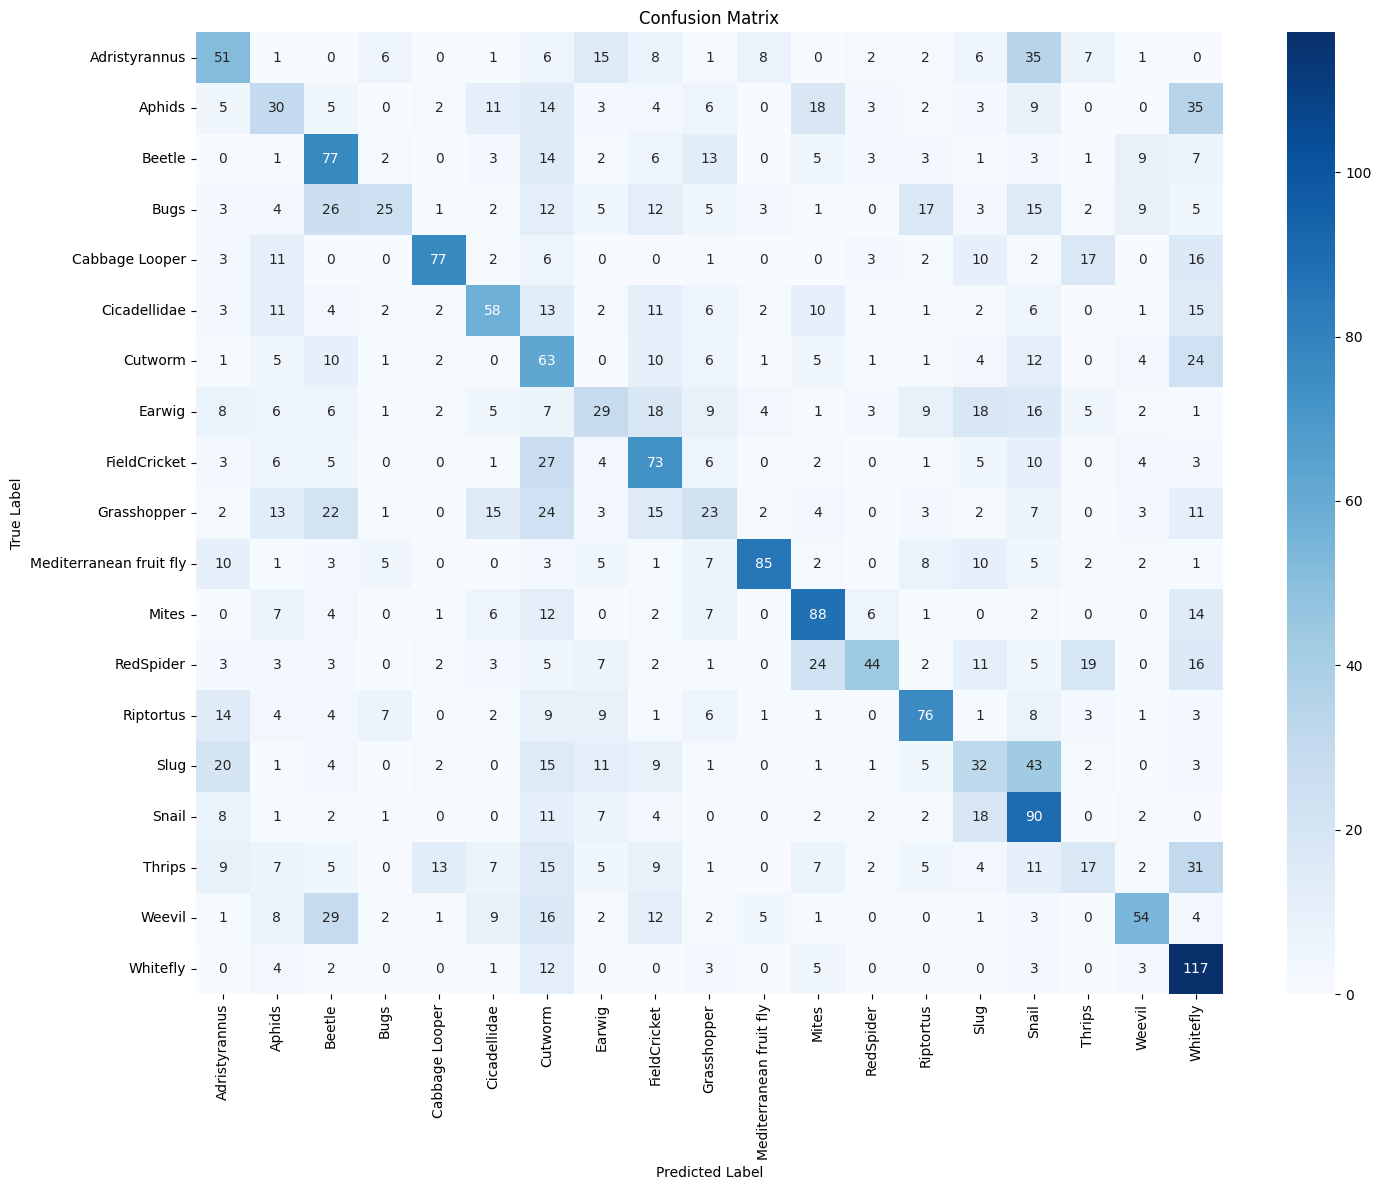

In [ ]:
# Calculate the confusion matrix
cm = confusion_matrix(val_labels, predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Inference on Sample Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


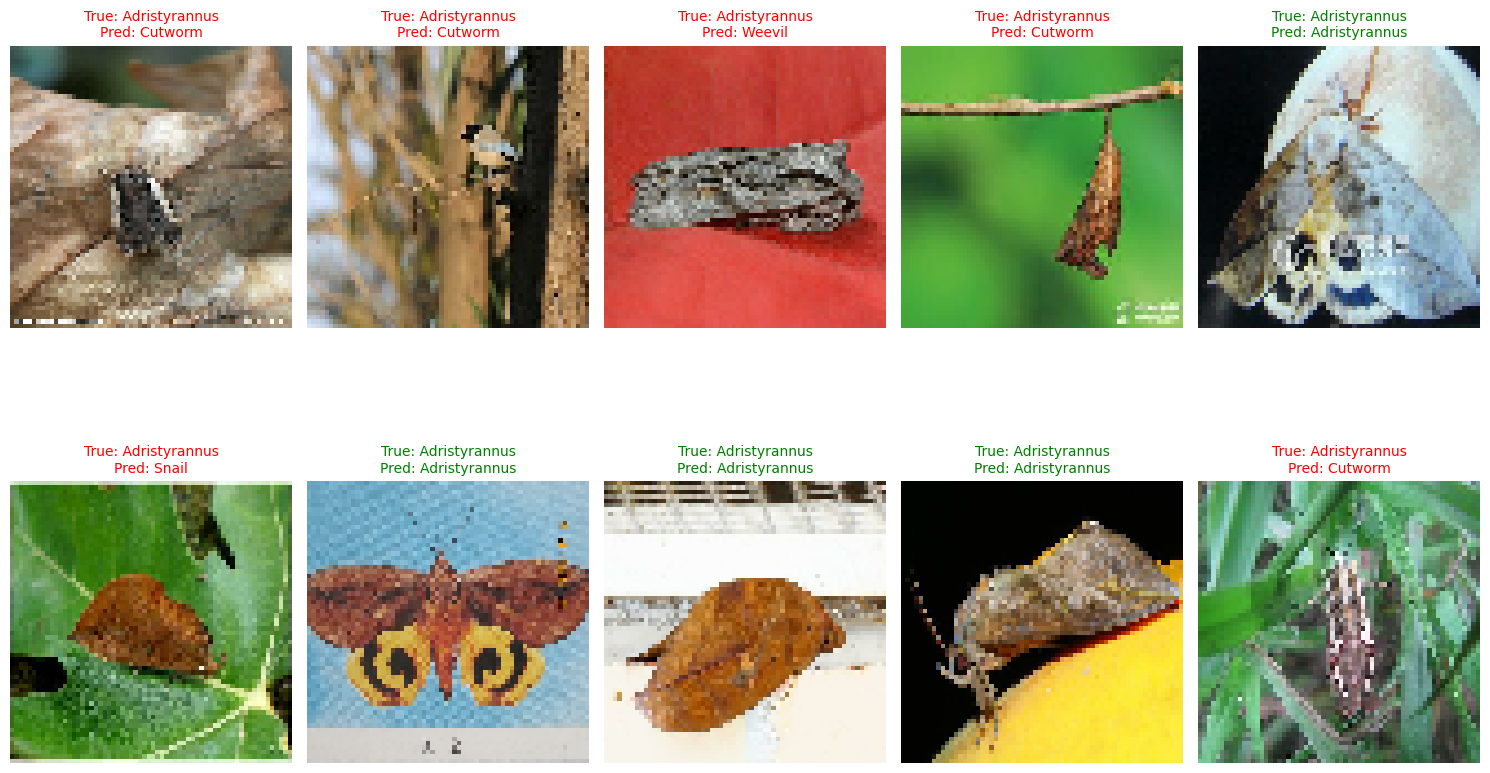

In [ ]:
# Take one batch from the validation dataset for inference demonstration
# It's better to convert the dataset to numpy arrays for easier indexing
for images, labels in val_ds.take(1):
    sample_images = images.numpy()
    sample_true_labels = np.argmax(labels.numpy(), axis=1)
    break

# Make predictions using the loaded model
sample_predictions = model.predict(sample_images)
sample_predicted_classes = np.argmax(sample_predictions, axis=1)

# Plot the sample images with predictions
plt.figure(figsize=(15, 10))
num_display = min(len(sample_images), 10) # Display up to 10 images from the batch

for i in range(num_display):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i])
    true_label_name = class_names[sample_true_labels[i]]
    predicted_label_name = class_names[sample_predicted_classes[i]]

    color = "green" if true_label_name == predicted_label_name else "red"
    plt.title(f"True: {true_label_name}\nPred: {predicted_label_name}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

#### Key observations about model performance

## Deeper Architecture with Regularization Layer

### Model Architecture

In [ ]:
from keras import regularizers

model_deeper = models.Sequential([
    # Block 1
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=INPUT_SHAPE),
    layers.BatchNormalization(),

    # Second Convolutional Block
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    # Third Convolutional Block
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),

    # Fourth Convolutional Block
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    #Block 3
    # Fifth Convolutional Block
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),

    # Sixth Convolutional Block
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Flatten the output
    layers.Flatten(),

    # Dense layers with Dropout and L2 regularization
    layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),

    # Output layer
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model_deeper.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │     8,389,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             

 Total params: 9,339,443 (35.63 MB)

 Trainable params: 9,338,547 (35.62 MB)

 Non-trainable params: 896 (3.50 KB)

### Model Training

In [ ]:
model_deeper.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ModelCheckpoint callback for the deeper model
model_checkpoint_deeper = ModelCheckpoint(
    filepath=os.path.join(model_save_dir, 'best_deeper_model.keras'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Early stopping callback for the deeper model
early_stopping_deeper = EarlyStopping(
    monitor='val_loss',
    patience=5, # Increased patience as deeper models might need more epochs to converge
    restore_best_weights=True
)

In [ ]:
print("Training Deeper Model...")
start_time_deeper = time.time()
history_deeper = model_deeper.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[early_stopping_deeper, model_checkpoint_deeper]
)
end_time_deeper = time.time()
training_time_deeper = end_time_deeper - start_time_deeper
print(f"Deeper Model Training Time: {training_time_deeper:.2f} seconds")

Training Deeper Model...
Epoch 1/20
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0838 - loss: 5.9921
Epoch 1: val_loss improved from None to 3.75686, saving model to /content/drive/MyDrive/AIML/Models/best_deeper_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AIML/Models/best_deeper_model.keras
891/891 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.1056 - loss: 4.9219 - val_accuracy: 0.1586 - val_loss: 3.7569
Epoch 2/20
890/891 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1662 - loss: 3.5040
Epoch 2: val_loss improved from 3.75686 to 3.12719, saving model to /content/drive/MyDrive/AIML/Models/best_deeper_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AIML/Models/best_deeper_model.keras
891/891 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.1857 - loss: 3.3325 - val_accuracy: 0.2007 - val_loss: 3.1272
Epoch 3/20
890/891 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2232 - loss: 3.0351
Epoch 3: val_loss improved from 3.12719 t

##### Plotting Training and Validation Loss/Accuracy for Deeper Model

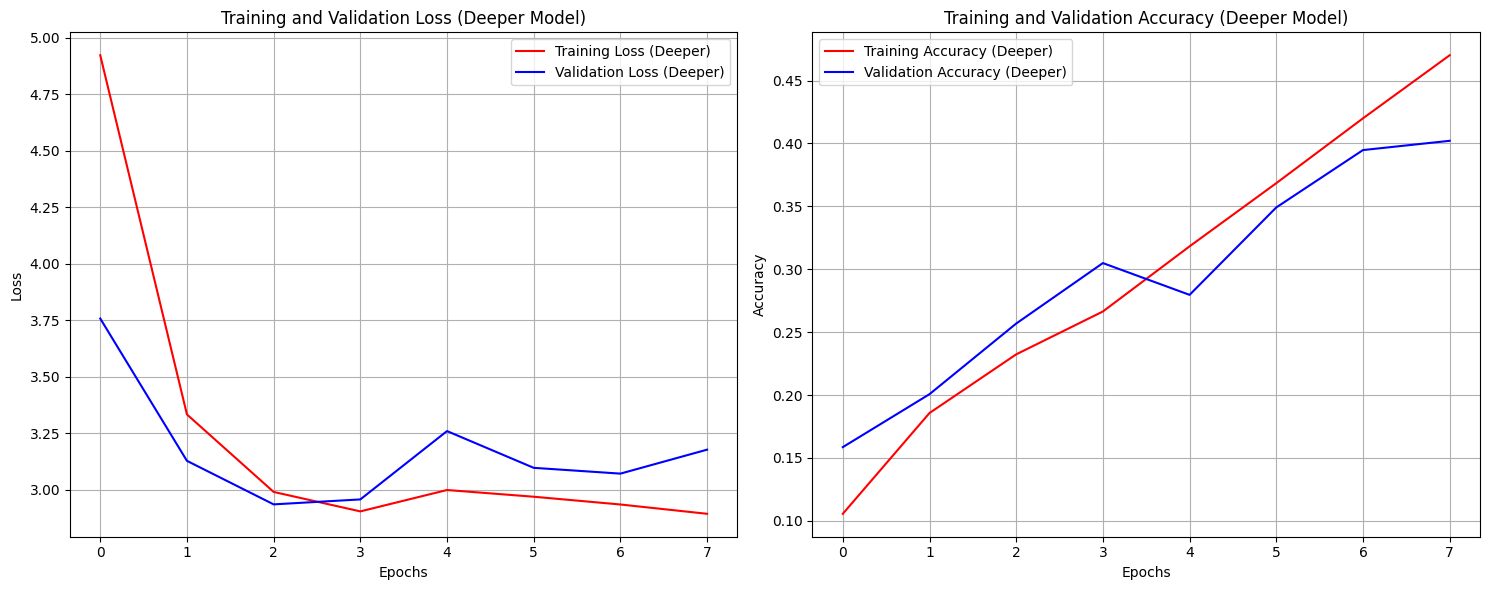

In [ ]:
# Get training and validation loss from history_deeper
loss_deeper = history_deeper.history['loss']
val_loss_deeper = history_deeper.history['val_loss']

# Get training and validation accuracy from history_deeper
accuracy_deeper = history_deeper.history['accuracy']
val_accuracy_deeper = history_deeper.history['val_accuracy']

epochs_deeper = range(len(loss_deeper))

plt.figure(figsize=(15, 6))

# Plot training and validation loss for deeper model
plt.subplot(1, 2, 1)
plt.plot(epochs_deeper, loss_deeper, 'r', label='Training Loss (Deeper)')
plt.plot(epochs_deeper, val_loss_deeper, 'b', label='Validation Loss (Deeper)')
plt.title('Training and Validation Loss (Deeper Model)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training and validation accuracy for deeper model
plt.subplot(1, 2, 2)
plt.plot(epochs_deeper, accuracy_deeper, 'r', label='Training Accuracy (Deeper)')
plt.plot(epochs_deeper, val_accuracy_deeper, 'b', label='Validation Accuracy (Deeper)')
plt.title('Training and Validation Accuracy (Deeper Model)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Model Evaluation

In [ ]:
# Load the saved best model
loaded_deeper_model = load_model(os.path.join(model_save_dir, 'best_deeper_model.keras'))

# Get true labels from the validation dataset (re-run in case kernel restarted or val_labels is not available)
val_labels_deeper = []
for _, labels in val_ds:
    val_labels_deeper.extend(np.argmax(labels.numpy(), axis=1))
val_labels_deeper = np.array(val_labels_deeper)

# Get predictions from the deeper model
val_predictions_deeper = model_deeper.predict(val_ds)
predicted_classes_deeper = np.argmax(val_predictions_deeper, axis=1)

# Ensure class names are available
if 'class_names' not in globals():
    # This block re-extracts class_names if the previous cell defining it was not run in this session
    val_path = '/content/drive/MyDrive/AIML/Assignment/Dataset/working/dataset_publish/balanced_pest_dataset/val'
    class_names = sorted(os.listdir(val_path))

# Generate a classification report for the deeper model
print("Classification Report (Deeper Model):")
print(classification_report(val_labels_deeper, predicted_classes_deeper, target_names=class_names))

90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
Classification Report (Deeper Model):
                         precision    recall  f1-score   support

          Adristyrannus       0.22      0.22      0.22       150
                 Aphids       0.18      0.37      0.24       150
                 Beetle       0.18      0.43      0.25       150
                   Bugs       0.17      0.01      0.01       150
         Cabbage Looper       0.42      0.59      0.49       150
           Cicadellidae       0.34      0.37      0.35       150
                Cutworm       0.14      0.27      0.19       150
                 Earwig       0.00      0.00      0.00       150
           FieldCricket       0.35      0.21      0.26       150
            Grasshopper       0.04      0.02      0.03       150
Mediterranean fruit fly       0.52      0.49      0.51       150
                  Mites       0.48      0.17      0.25       150
              RedSpider       0.52      0.19      0.28       150
           

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


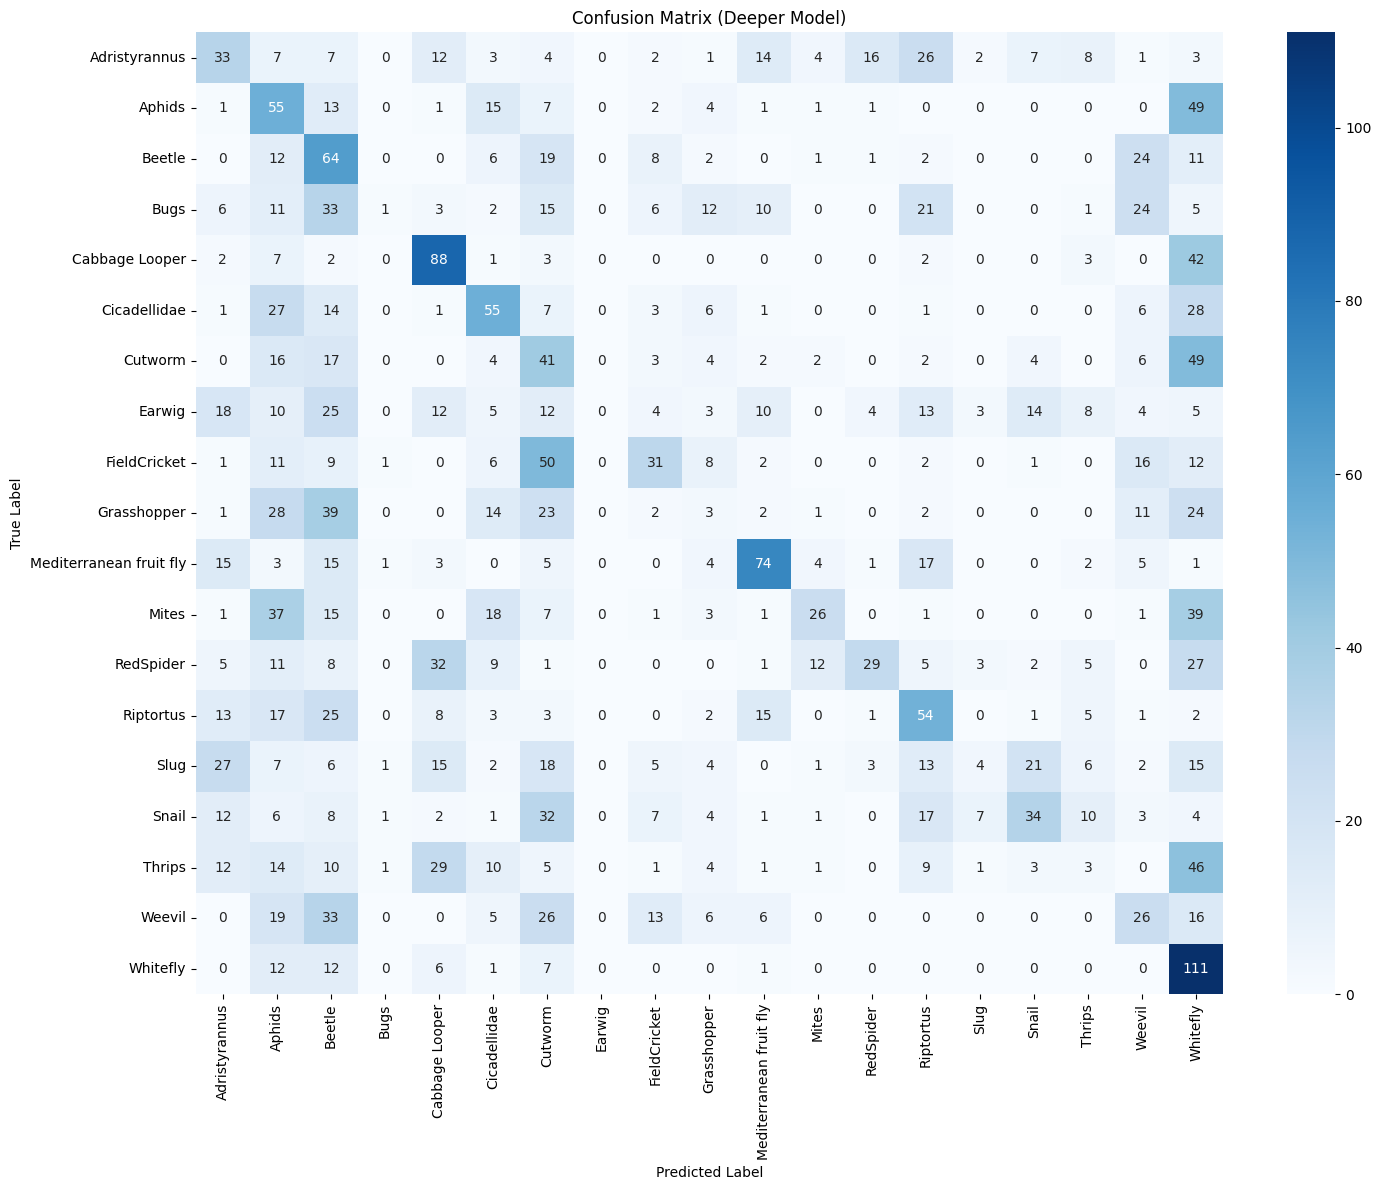

In [ ]:
# Calculate the confusion matrix for the deeper model
cm_deeper = confusion_matrix(val_labels_deeper, predicted_classes_deeper)

# Plot the confusion matrix for the deeper model
plt.figure(figsize=(15, 12))
sns.heatmap(cm_deeper, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Deeper Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##### Inference on Sample Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


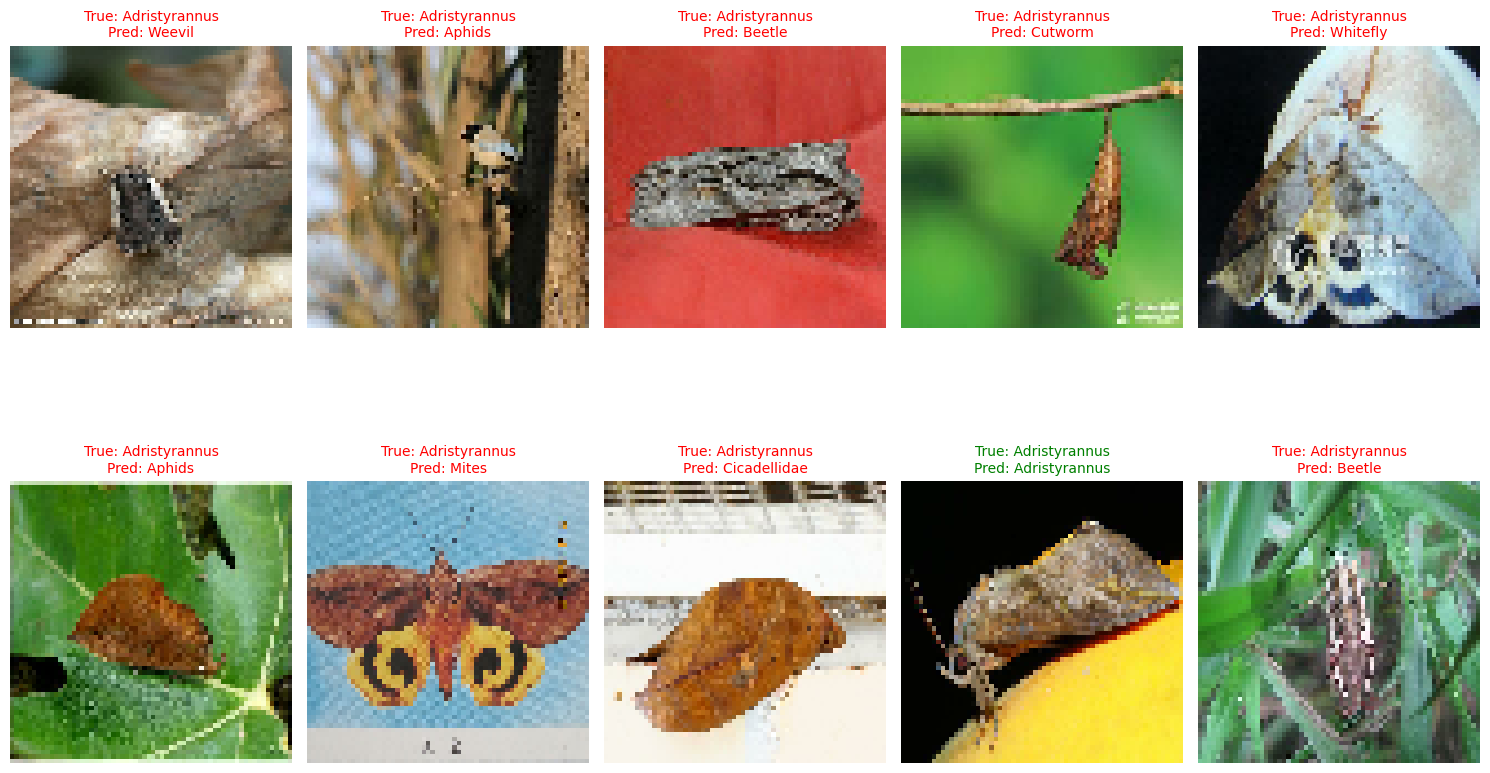

In [ ]:
# Take one batch from the validation dataset for inference demonstration
# It's better to convert the dataset to numpy arrays for easier indexing
for images, labels in val_ds.take(1):
    sample_images_deeper = images.numpy()
    sample_true_labels_deeper = np.argmax(labels.numpy(), axis=1)
    break

# Make predictions using the deeper model
sample_predictions_deeper = model_deeper.predict(sample_images_deeper)
sample_predicted_classes_deeper = np.argmax(sample_predictions_deeper, axis=1)

# Plot the sample images with predictions from the deeper model
plt.figure(figsize=(15, 10))
num_display = min(len(sample_images_deeper), 10) # Display up to 10 images from the batch

for i in range(num_display):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images_deeper[i])
    true_label_name = class_names[sample_true_labels_deeper[i]]
    predicted_label_name = class_names[sample_predicted_classes_deeper[i]]

    color = "green" if true_label_name == predicted_label_name else "red"
    plt.title(f"True: {true_label_name}\nPred: {predicted_label_name}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

##### Key observations about model performance

## Experimentation and Comparative Analysis

### 1. Baseline vs. Deeper Model Performance

##### Comparison of Training and Validation Curves: Baseline vs. Deeper Model

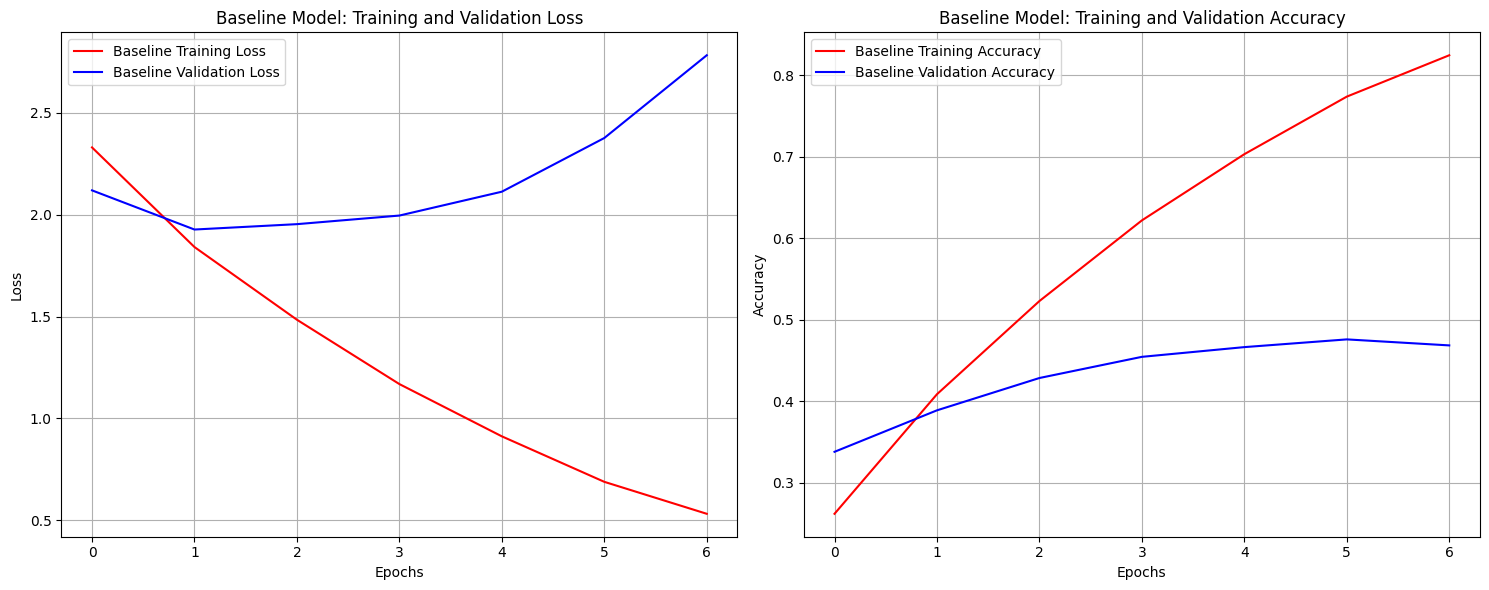

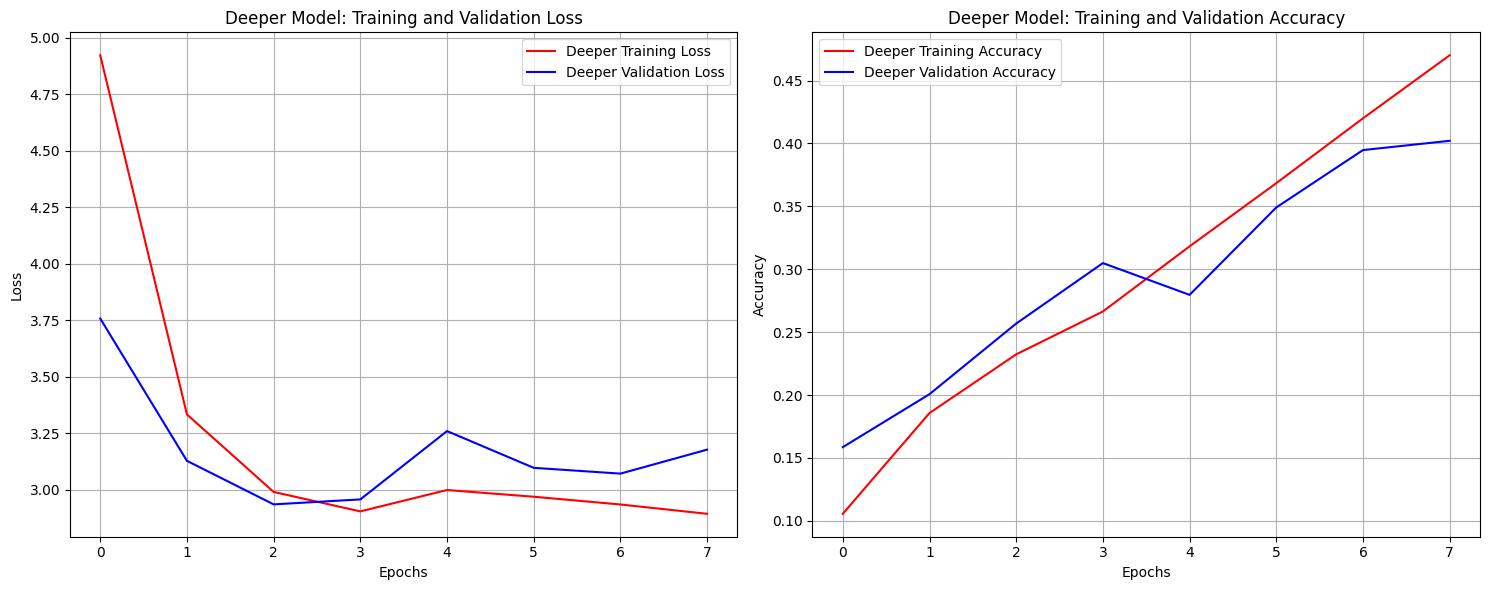

In [ ]:
plt.figure(figsize=(15, 6))

# Baseline Model: Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, 'r', label='Baseline Training Loss')
plt.plot(epochs, val_loss, 'b', label='Baseline Validation Loss')
plt.title('Baseline Model: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Baseline Model: Training and Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy, 'r', label='Baseline Training Accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Baseline Validation Accuracy')
plt.title('Baseline Model: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))

# Deeper Model: Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_deeper, loss_deeper, 'r', label='Deeper Training Loss')
plt.plot(epochs_deeper, val_loss_deeper, 'b', label='Deeper Validation Loss')
plt.title('Deeper Model: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Deeper Model: Training and Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_deeper, accuracy_deeper, 'r', label='Deeper Training Accuracy')
plt.plot(epochs_deeper, val_accuracy_deeper, 'b', label='Deeper Validation Accuracy')
plt.title('Deeper Model: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##### Performance differences found

### 2. Computational Efficiency

In [ ]:
print(f"Baseline Model Training Time: {training_time_baseline:.2f} seconds")
print(f"Deeper Model Training Time: {training_time_deeper:.2f} seconds")

Baseline Model Training Time: 1793.04 seconds
Deeper Model Training Time: 96.33 seconds


###### The trade - offs between model complexity and efficiency.


### 3. Optimizer Analysis: SGD vs Adam

In [ ]:
model_deeper_sgd = models.Sequential([
    # Block 1
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=INPUT_SHAPE),
    layers.BatchNormalization(),

    # Second Convolutional Block
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    # Third Convolutional Block
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),

    # Fourth Convolutional Block
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    #Block 3
    # Fifth Convolutional Block
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),

    # Sixth Convolutional Block
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Flatten the output
    layers.Flatten(),

    # Dense layers with Dropout and L2 regularization
    layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),

    # Output layer
    layers.Dense(NUM_CLASSES, activation='softmax')
])

print("Deeper Model (SGD) Summary:")
model_deeper_sgd.summary()


Deeper Model (SGD) Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │     8,389,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             

 Total params: 9,339,443 (35.63 MB)

 Trainable params: 9,338,547 (35.62 MB)

 Non-trainable params: 896 (3.50 KB)

#### Training with SGD Optimizer

In [ ]:
# Configure SGD optimizer
sgd_optimizer = optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

model_deeper_sgd.compile(
    optimizer=sgd_optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ModelCheckpoint callback for the SGD model
model_checkpoint_sgd = ModelCheckpoint(
    filepath=os.path.join(model_save_dir, 'best_deeper_model_sgd.keras'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Early stopping callback for the SGD model
early_stopping_sgd = EarlyStopping(
    monitor='val_loss',
    patience=10, # Increased patience as SGD might take longer to converge
    restore_best_weights=True
)



In [ ]:
print("Training Deeper Model with SGD...")
start_time_deeper = time.time()
history_deeper_sgd = model_deeper_sgd.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[early_stopping_sgd, model_checkpoint_sgd]
)
end_time_baseline = time.time()
training_time_sgd = end_time_baseline - start_time_baseline
print(f"Deeper Model(SGD) Training Time: {training_time_sgd:.2f} seconds")

Training Deeper Model with SGD...
Epoch 1/20
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0618 - loss: 5.8601
Epoch 1: val_loss improved from None to 4.77855, saving model to /content/drive/MyDrive/AIML/Models/best_deeper_model_sgd.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AIML/Models/best_deeper_model_sgd.keras
891/891 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - accuracy: 0.0780 - loss: 5.4499 - val_accuracy: 0.1544 - val_loss: 4.7786
Epoch 2/20
886/891 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1582 - loss: 4.6141
Epoch 2: val_loss improved from 4.77855 to 4.21880, saving model to /content/drive/MyDrive/AIML/Models/best_deeper_model_sgd.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AIML/Models/best_deeper_model_sgd.keras
891/891 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.1882 - loss: 4.3856 - val_accuracy: 0.1765 - val_loss: 4.2188
Epoch 3/20
890/891 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2464 - loss: 3.8423
Epoch 3: val_los

#### Training with Adam Optimizer




In [ ]:
# history_deeper already contains the training results with Adam
history_deeper_adam = history_deeper

print("Adam Optimizer history is available as 'history_deeper_adam'.")

Adam Optimizer history is available as 'history_deeper_adam'.


#### Plotting Training and Validation Loss/Accuracy for SGD and Adam Models

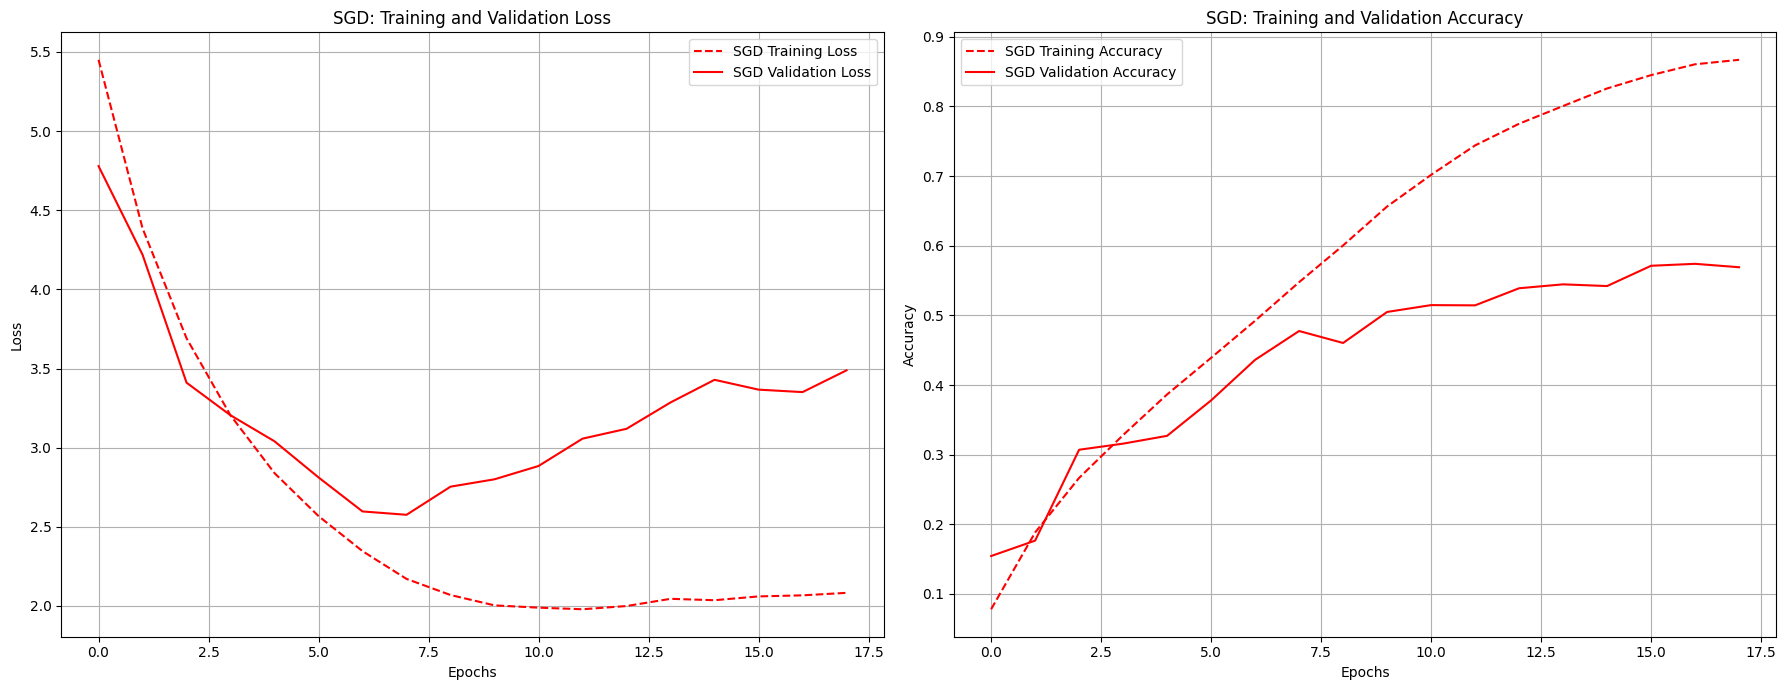

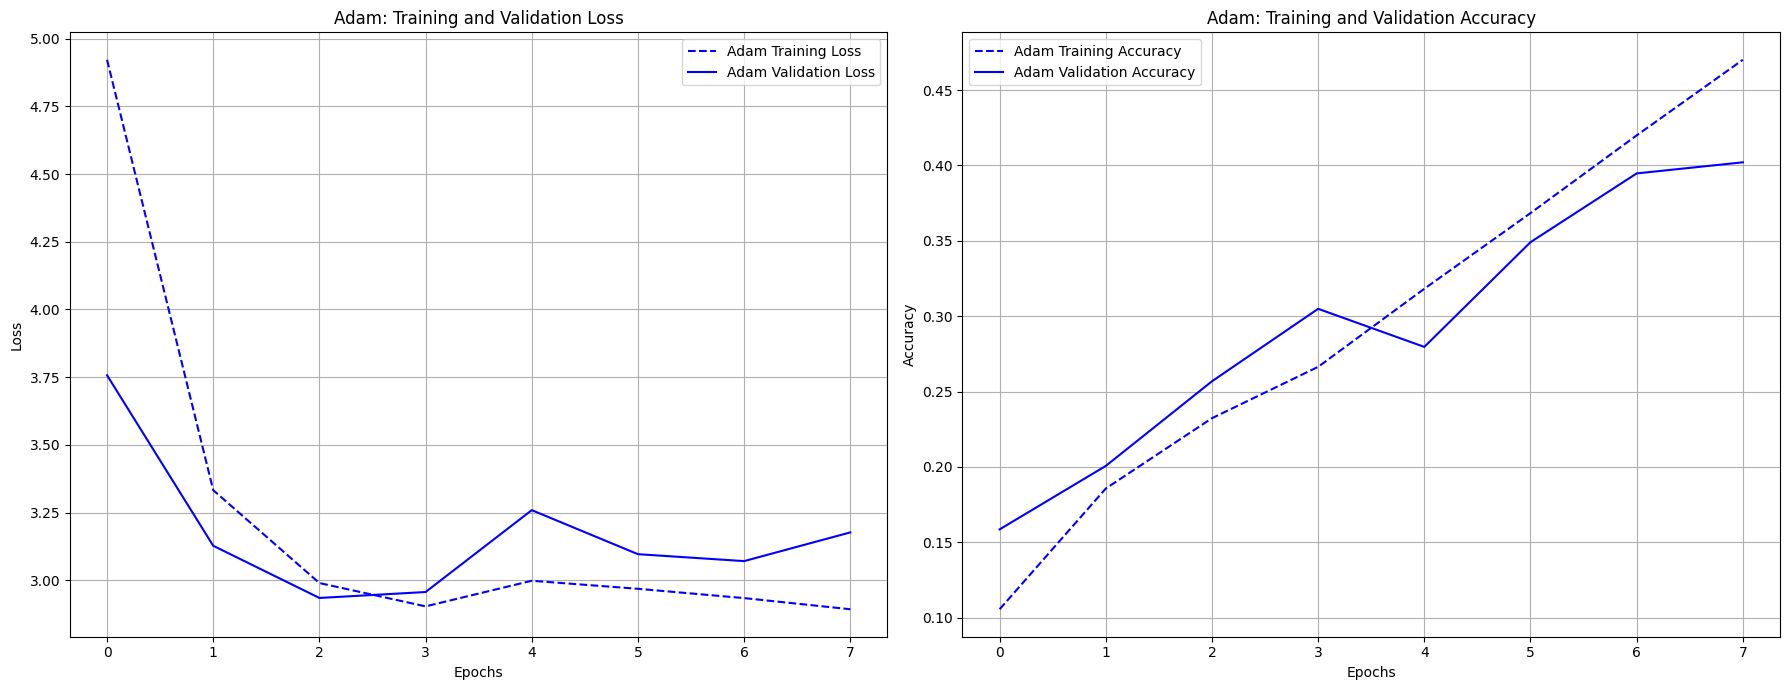

In [ ]:
plt.figure(figsize=(18, 7))

# --- SGD Model Plots ---
# Plot Training and Validation Loss for SGD
plt.subplot(1, 2, 1)
plt.plot(history_deeper_sgd.history['loss'], 'r--', label='SGD Training Loss')
plt.plot(history_deeper_sgd.history['val_loss'], 'r', label='SGD Validation Loss')
plt.title('SGD: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training and Validation Accuracy for SGD
plt.subplot(1, 2, 2)
plt.plot(history_deeper_sgd.history['accuracy'], 'r--', label='SGD Training Accuracy')
plt.plot(history_deeper_sgd.history['val_accuracy'], 'r', label='SGD Validation Accuracy')
plt.title('SGD: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 7))

# --- Adam Model Plots ---
# Plot Training and Validation Loss for Adam
plt.subplot(1, 2, 1)
plt.plot(history_deeper_adam.history['loss'], 'b--', label='Adam Training Loss')
plt.plot(history_deeper_adam.history['val_loss'], 'b', label='Adam Validation Loss')
plt.title('Adam: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training and Validation Accuracy for Adam
plt.subplot(1, 2, 2)
plt.plot(history_deeper_adam.history['accuracy'], 'b--', label='Adam Training Accuracy')
plt.plot(history_deeper_adam.history['val_accuracy'], 'b', label='Adam Validation Accuracy')
plt.title('Adam: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### Model Evaluation: SGD vs. Adam

In [ ]:
# Evaluate the SGD model
val_predictions_deeper_sgd = model_deeper_sgd.predict(val_ds)
predicted_classes_deeper_sgd = np.argmax(val_predictions_deeper_sgd, axis=1)

print("Classification Report (Deeper Model with SGD):")
print(classification_report(val_labels_deeper, predicted_classes_deeper_sgd, target_names=class_names))

# Evaluate the Adam model
# (val_predictions_deeper and predicted_classes_deeper should already exist from previous execution)
print("\nClassification Report (Deeper Model with Adam, from previous run):")
print(classification_report(val_labels_deeper, predicted_classes_deeper, target_names=class_names))

90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
Classification Report (Deeper Model with SGD):
                         precision    recall  f1-score   support

          Adristyrannus       0.70      0.39      0.50       150
                 Aphids       0.33      0.37      0.35       150
                 Beetle       0.38      0.53      0.44       150
                   Bugs       0.64      0.31      0.42       150
         Cabbage Looper       0.81      0.61      0.70       150
           Cicadellidae       0.49      0.46      0.47       150
                Cutworm       0.22      0.52      0.31       150
                 Earwig       0.33      0.38      0.35       150
           FieldCricket       0.44      0.59      0.50       150
            Grasshopper       0.27      0.22      0.24       150
Mediterranean fruit fly       0.70      0.79      0.75       150
                  Mites       0.65      0.64      0.64       150
              RedSpider       0.69      0.28      0.40       150
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 4. Ablation Study



#### Deeper Model without Dropout

In [ ]:
model_deeper_no_dropout = models.Sequential([
    # Block 1
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=INPUT_SHAPE),
    layers.BatchNormalization(),

    # Second Convolutional Block
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    # Third Convolutional Block
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),

    # Fourth Convolutional Block
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    #Block 3
    # Fifth Convolutional Block
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),

    # Sixth Convolutional Block
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Flatten the output
    layers.Flatten(),

    # Dense layers with Dropout and L2 regularization
    layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),

    # Output layer
    layers.Dense(NUM_CLASSES, activation='softmax')
])

print("Deeper Model (No Dropout) Summary:")
model_deeper_no_dropout.summary()


Deeper Model (No Dropout) Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1024)           │     8,389,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 19)             │         4,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,339,443 (35.63 MB)

 Trainable params: 9,338,547 (35.62 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
model_deeper_no_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_checkpoint_no_dropout = ModelCheckpoint(
    filepath=os.path.join(model_save_dir, 'best_deeper_model_no_dropout.keras'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stopping_no_dropout = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)



In [ ]:
print("Training Deeper Model without Dropout...")
start_time_deeper = time.time()
history_deeper_no_dropout = model_deeper_no_dropout.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[early_stopping_no_dropout, model_checkpoint_no_dropout]
)
end_time_baseline = time.time()
training_time_no_dropout = end_time_baseline - start_time_baseline
print(f"Deeper Model (No Dropout) Training Time: {training_time_no_dropout:.2f} seconds")

Training Deeper Model without Dropout...
Epoch 1/20
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2109 - loss: 4.7842
Epoch 1: val_loss improved from None to 3.18535, saving model to /content/drive/MyDrive/AIML/Models/best_deeper_model_no_dropout.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AIML/Models/best_deeper_model_no_dropout.keras
891/891 ━━━━━━━━━━━━━━━━━━━━ 36s 27ms/step - accuracy: 0.2744 - loss: 3.7070 - val_accuracy: 0.2498 - val_loss: 3.1854
Epoch 2/20
887/891 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3682 - loss: 2.5692
Epoch 2: val_loss improved from 3.18535 to 2.56715, saving model to /content/drive/MyDrive/AIML/Models/best_deeper_model_no_dropout.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AIML/Models/best_deeper_model_no_dropout.keras
891/891 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.3923 - loss: 2.4627 - val_accuracy: 0.3849 - val_loss: 2.5671
Epoch 3/20
890/891 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4

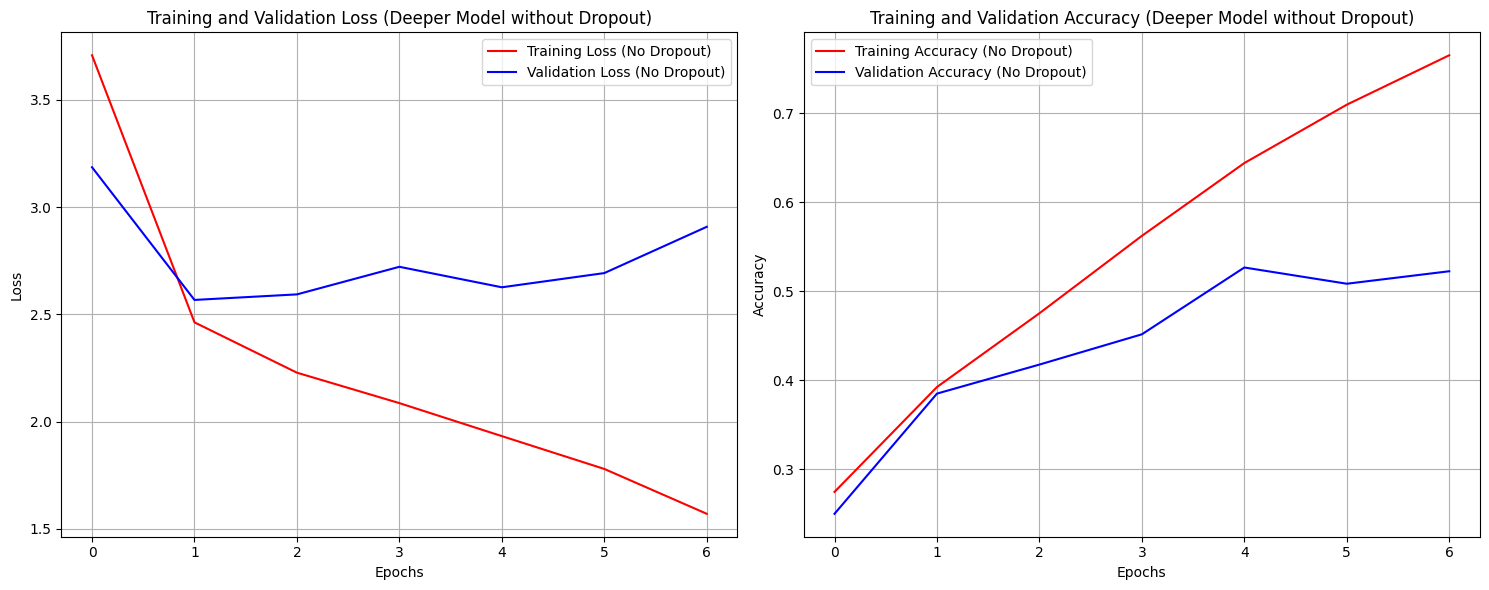

In [ ]:
# Get training and validation loss from history_deeper_no_dropout
loss_no_dropout = history_deeper_no_dropout.history['loss']
val_loss_no_dropout = history_deeper_no_dropout.history['val_loss']

# Get training and validation accuracy from history_deeper_no_dropout
accuracy_no_dropout = history_deeper_no_dropout.history['accuracy']
val_accuracy_no_dropout = history_deeper_no_dropout.history['val_accuracy']

epochs_no_dropout = range(len(loss_no_dropout))

plt.figure(figsize=(15, 6))

# Plot training and validation loss for deeper model without dropout
plt.subplot(1, 2, 1)
plt.plot(epochs_no_dropout, loss_no_dropout, 'r', label='Training Loss (No Dropout)')
plt.plot(epochs_no_dropout, val_loss_no_dropout, 'b', label='Validation Loss (No Dropout)')
plt.title('Training and Validation Loss (Deeper Model without Dropout)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training and validation accuracy for deeper model without dropout
plt.subplot(1, 2, 2)
plt.plot(epochs_no_dropout, accuracy_no_dropout, 'r', label='Training Accuracy (No Dropout)')
plt.plot(epochs_no_dropout, val_accuracy_no_dropout, 'b', label='Validation Accuracy (No Dropout)')
plt.title('Training and Validation Accuracy (Deeper Model without Dropout)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print(f"Deeper Model (No Dropout) Training Time: {training_time_no_dropout:.2f} seconds")

# Load the saved best model without dropout
loaded_deeper_no_dropout_model = load_model(os.path.join(model_save_dir, 'best_deeper_model_no_dropout.keras'))

# Get predictions from the deeper model without dropout
val_predictions_deeper_no_dropout = loaded_deeper_no_dropout_model.predict(val_ds)
predicted_classes_deeper_no_dropout = np.argmax(val_predictions_deeper_no_dropout, axis=1)

# Generate a classification report for the deeper model without dropout
print("\nClassification Report (Deeper Model without Dropout):")
print(classification_report(val_labels_deeper, predicted_classes_deeper_no_dropout, target_names=class_names))

Deeper Model (No Dropout) Training Time: 2220.26 seconds
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step

Classification Report (Deeper Model without Dropout):
                         precision    recall  f1-score   support

          Adristyrannus       0.60      0.41      0.49       150
                 Aphids       0.21      0.07      0.11       150
                 Beetle       0.44      0.12      0.19       150
                   Bugs       0.31      0.23      0.26       150
         Cabbage Looper       0.85      0.50      0.63       150
           Cicadellidae       0.45      0.45      0.45       150
                Cutworm       0.23      0.34      0.27       150
                 Earwig       0.26      0.28      0.27       150
           FieldCricket       0.24      0.69      0.35       150
            Grasshopper       0.25      0.10      0.14       150
Mediterranean fruit fly       0.59      0.64      0.61       150
                  Mites       0.41      0.69      0.51       150
  

### 5. Challenges and Observations



# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning).


## Necessary Imports

In [ ]:
from tensorflow.keras.applications import MobileNetV2


## Loading and Adapting a Pre - Trained Model

In [ ]:
# Load the MobileNetV2 model with pre-trained ImageNet weights
# Exclude the top (classification) layer as we will add our own
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Display the model summary
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
# Freeze the base model's layers so they are not updated during training
base_model.trainable = False

# Create a new model on top of the base_model's output
model_transfer_learning = models.Sequential([
    base_model, # The frozen pre-trained model
    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)), # Added L2 regularization
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax') # Output layer for your specific number of classes
])

model_transfer_learning.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │    16,056,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 19)             │         4,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,319,443 (69.88 MB)

 Trainable params: 16,061,459 (61.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Model Training and Fine - Tuning

In [ ]:
INPUT_SHAPE = (224, 224, 3) # (height, width, channels)

print(f"Updated input image shape: {INPUT_SHAPE}")
print(f"Number of classes: {NUM_CLASSES}")

# Re-define IMG_HEIGHT and IMG_WIDTH based on the new INPUT_SHAPE
IMG_HEIGHT = INPUT_SHAPE[0]
IMG_WIDTH = INPUT_SHAPE[1]

# Re-create data generators with the updated image size
print(f"\nLoading training data from: {train_path} with new image size {IMG_HEIGHT}x{IMG_WIDTH}")
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123 # For reproducibility
)

print(f"\nLoading validation data from: {val_path} with new image size {IMG_HEIGHT}x{IMG_WIDTH}")
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False, # Typically no need to shuffle validation data
    seed=123 # For reproducibility
)

# Normalize pixel values to [0, 1]
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print(f"\nLoading test data from: {test_path} with new image size {IMG_HEIGHT}x{IMG_WIDTH}")
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False, # Test data should not be shuffled
    seed=123 # For reproducibility
)

test_ds = test_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("\nData generators re-prepared with new image size.")

Updated input image shape: (224, 224, 3)
Number of classes: 19

Loading training data from: /content/drive/MyDrive/AIML/Assignment/Dataset/working/dataset_publish/balanced_pest_dataset/train with new image size 224x224
Found 28500 files belonging to 19 classes.

Loading validation data from: /content/drive/MyDrive/AIML/Assignment/Dataset/working/dataset_publish/balanced_pest_dataset/val with new image size 224x224
Found 2850 files belonging to 19 classes.

Loading test data from: /content/drive/MyDrive/AIML/Assignment/Dataset/working/dataset_publish/balanced_pest_dataset/test with new image size 224x224
Found 2850 files belonging to 19 classes.

Data generators re-prepared with new image size.


### Model training

In [ ]:
# Compile the model
model_transfer_learning.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks for saving the best model and early stopping
model_checkpoint_tl = ModelCheckpoint(
    filepath=os.path.join(model_save_dir, 'best_transfer_learning_model.keras'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stopping_tl = EarlyStopping(
    monitor='val_loss',
    patience=5, # You can adjust patience based on convergence behavior
    restore_best_weights=True
)



In [ ]:
print("Training Transfer Learning Model...")
start_time_tl = time.time()
history_transfer_learning = model_transfer_learning.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[early_stopping_tl, model_checkpoint_tl]
)
end_time_tl = time.time()
training_time_tl = end_time_tl - start_time_tl
print(f"Transfer Learning Model Training Time: {training_time_tl:.2f} seconds")

Training Transfer Learning Model...
Epoch 1/20
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.2425 - loss: 4.0880
Epoch 1: val_loss improved from None to 2.28011, saving model to /content/drive/MyDrive/AIML/Models/best_transfer_learning_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AIML/Models/best_transfer_learning_model.keras
891/891 ━━━━━━━━━━━━━━━━━━━━ 108s 98ms/step - accuracy: 0.2863 - loss: 3.0890 - val_accuracy: 0.4888 - val_loss: 2.2801
Epoch 2/20
889/891 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3505 - loss: 2.7833
Epoch 2: val_loss improved from 2.28011 to 2.09899, saving model to /content/drive/MyDrive/AIML/Models/best_transfer_learning_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AIML/Models/best_transfer_learning_model.keras
891/891 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - accuracy: 0.3554 - loss: 2.6877 - val_accuracy: 0.5614 - val_loss: 2.0990
Epoch 3/20
889/891 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3

### Fine-Tuning

1.  **Unfreeze** the entire base_model (or specific layers within it).
2.  **Re-compile** the model_transfer_learning with a much lower learning rate.
3.  **Continue training** the model for a few more epochs.

In [ ]:
# Unfreeze the base model
base_model.trainable = True

# Use a very low learning rate for fine-tuning to avoid destroying learned weights
model_transfer_learning.compile(
    optimizer=keras.optimizers.Adam(1e-5), # Lower learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_transfer_learning.summary()



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │    16,056,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 19)             │         4,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,319,443 (69.88 MB)

 Trainable params: 18,285,331 (69.75 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
print("Fine-Tuning Transfer Learning Model...")
start_time_fine_tune = time.time()
history_fine_tune = model_transfer_learning.fit(
    train_ds,
    epochs=10, # Train for a few more epochs
    validation_data=val_ds,
    callbacks=[early_stopping_tl, model_checkpoint_tl]
)
end_time_fine_tune = time.time()
training_time_fine_tune = end_time_fine_tune - start_time_fine_tune
print(f"Transfer Learning Model Fine-Tuning Time: {training_time_fine_tune:.2f} seconds")

Fine-Tuning Transfer Learning Model...
Epoch 1/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4568 - loss: 2.3269
Epoch 1: val_loss improved from 1.72221 to 1.63543, saving model to /content/drive/MyDrive/AIML/Models/best_transfer_learning_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AIML/Models/best_transfer_learning_model.keras
891/891 ━━━━━━━━━━━━━━━━━━━━ 158s 117ms/step - accuracy: 0.4992 - loss: 2.1669 - val_accuracy: 0.6919 - val_loss: 1.6354
Epoch 2/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5741 - loss: 1.8915
Epoch 2: val_loss improved from 1.63543 to 1.57410, saving model to /content/drive/MyDrive/AIML/Models/best_transfer_learning_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AIML/Models/best_transfer_learning_model.keras
891/891 ━━━━━━━━━━━━━━━━━━━━ 62s 69ms/step - accuracy: 0.5846 - loss: 1.8460 - val_accuracy: 0.7102 - val_loss: 1.5741
Epoch 3/10
890/891 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accur

### Model Evaluation and Prediction

In [ ]:
# Load the best saved fine-tuned transfer learning model
loaded_transfer_learning_model = load_model(os.path.join(model_save_dir, 'best_transfer_learning_model.keras'))

# Get true labels from the validation dataset (ensure val_labels are updated for resized images)
# Re-extract val_labels in case of kernel restart or new data generation
val_labels_tl = []
for _, labels in val_ds:
    val_labels_tl.extend(np.argmax(labels.numpy(), axis=1))
val_labels_tl = np.array(val_labels_tl)

# Get predictions from the loaded fine-tuned model on the validation set
val_predictions_tl = loaded_transfer_learning_model.predict(val_ds)
predicted_classes_tl = np.argmax(val_predictions_tl, axis=1)

# Ensure class_names are available (re-extract if necessary)
if 'class_names' not in globals():
    val_path = '/content/drive/MyDrive/AIML/Assignment/Dataset/working/dataset_publish/balanced_pest_dataset/val'
    class_names = sorted(os.listdir(val_path))

# Generate a classification report for the fine-tuned model
print("Classification Report (Fine-Tuned Transfer Learning Model):")
print(classification_report(val_labels_tl, predicted_classes_tl, target_names=class_names))

90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step
Classification Report (Fine-Tuned Transfer Learning Model):
                         precision    recall  f1-score   support

          Adristyrannus       0.90      0.64      0.75       150
                 Aphids       0.57      0.64      0.61       150
                 Beetle       0.62      0.82      0.70       150
                   Bugs       0.85      0.85      0.85       150
         Cabbage Looper       0.93      0.80      0.86       150
           Cicadellidae       0.72      0.85      0.78       150
                Cutworm       0.73      0.71      0.72       150
                 Earwig       0.84      0.68      0.75       150
           FieldCricket       0.77      0.93      0.84       150
            Grasshopper       0.69      0.53      0.60       150
Mediterranean fruit fly       0.95      0.90      0.92       150
                  Mites       0.70      0.79      0.75       150
              RedSpider       0.83      0.59      0.6

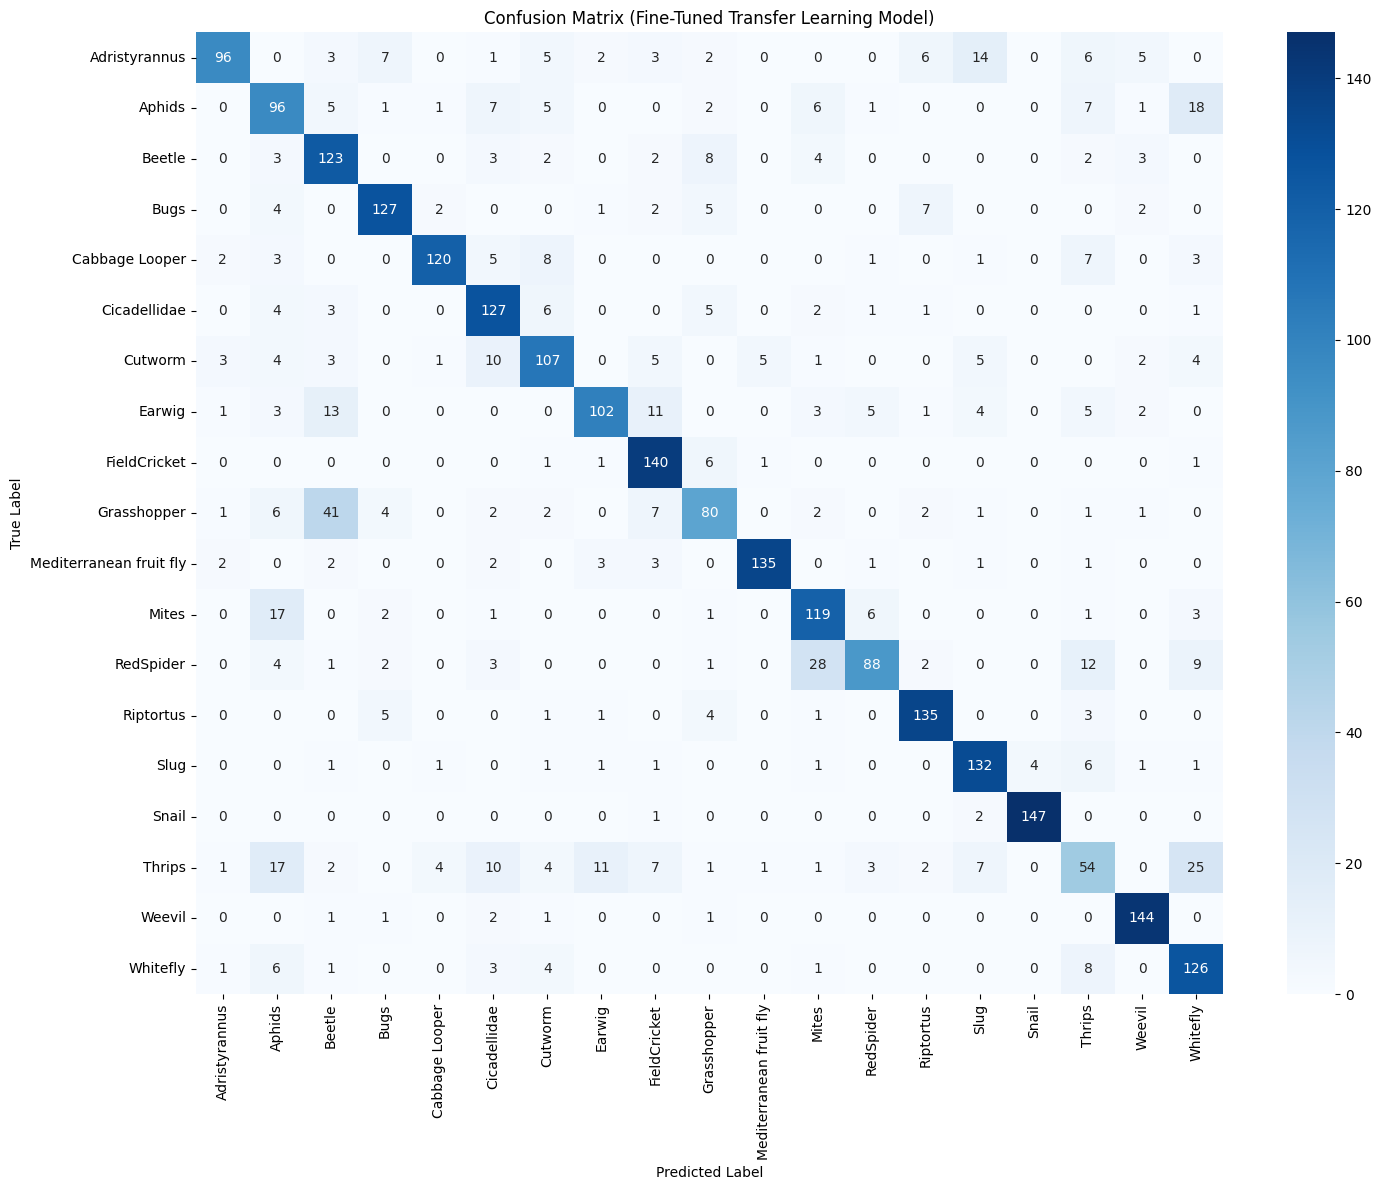

In [ ]:
# Calculate the confusion matrix for the fine-tuned model
cm_tl = confusion_matrix(val_labels_tl, predicted_classes_tl)

# Plot the confusion matrix for the fine-tuned model
plt.figure(figsize=(15, 12))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Fine-Tuned Transfer Learning Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Inference on Sample Images (Fine-Tuned Transfer Learning Model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


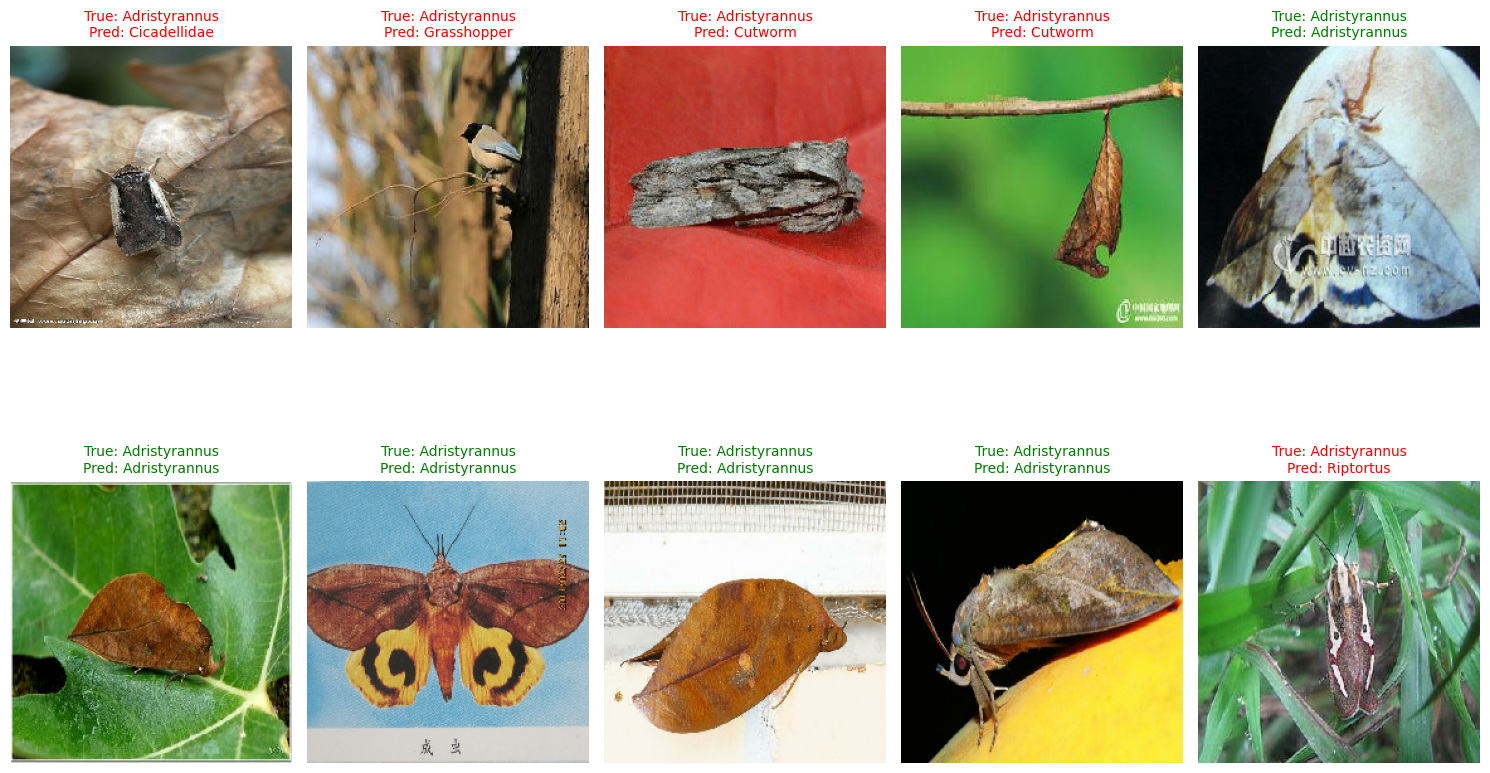

In [ ]:
# Take one batch from the validation dataset for inference demonstration
# It's better to convert the dataset to numpy arrays for easier indexing
for images, labels in val_ds.take(1):
    sample_images_tl = images.numpy()
    sample_true_labels_tl = np.argmax(labels.numpy(), axis=1)
    break

# Make predictions using the fine-tuned model
sample_predictions_tl = loaded_transfer_learning_model.predict(sample_images_tl)
sample_predicted_classes_tl = np.argmax(sample_predictions_tl, axis=1)

# Plot the sample images with predictions from the fine-tuned model
plt.figure(figsize=(15, 10))
num_display = min(len(sample_images_tl), 10) # Display up to 10 images from the batch

for i in range(num_display):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images_tl[i])
    true_label_name = class_names[sample_true_labels_tl[i]]
    predicted_label_name = class_names[sample_predicted_classes_tl[i]]

    color = "green" if true_label_name == predicted_label_name else "red"
    plt.title(f"True: {true_label_name}\nPred: {predicted_label_name}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Comparative Analysis with Baseline, Deeper Models, and Transfer learning model on Test Set



In [ ]:
loaded_baseline_model = load_model(os.path.join(model_save_dir, 'best_baseline_model.keras'))
loaded_deeper_model = load_model(os.path.join(model_save_dir, 'best_deeper_model.keras'))
loaded_transfer_learning_model_test = load_model(os.path.join(model_save_dir, 'best_transfer_learning_model.keras'))
loaded_deeper_model_sgd = load_model(os.path.join(model_save_dir, 'best_deeper_model_sgd.keras'))
loaded_deeper_no_dropout_model = load_model(os.path.join(model_save_dir, 'best_deeper_model_no_dropout.keras'))

### Evaluation for Baseline and Deeper Models

In [ ]:
# Define image size for baseline and deeper models
IMG_HEIGHT_64 = 64
IMG_WIDTH_64 = 64

print(f"Loading validation data for 64x64 input from: {val_path}")
val_ds_64x64 = tf.keras.utils.image_dataset_from_directory(
    val_path,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT_64, IMG_WIDTH_64),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    shuffle=False, # Validation data should not be shuffled
    seed=123 # For reproducibility
)

val_ds_64x64 = val_ds_64x64.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Validation dataset for 64x64 models prepared.")

# Extract true labels from the 64x64 validation dataset
y_true_64x64 = []
for _, labels in val_ds_64x64:
    y_true_64x64.extend(np.argmax(labels.numpy(), axis=1))
y_true_64x64 = np.array(y_true_64x64)

# List of models trained with 64x64 input to evaluate
model_list_64x64 = {
    "Baseline": loaded_baseline_model,
    "Deeper (Adam)": loaded_deeper_model,
    "Deeper (SGD)": loaded_deeper_model_sgd,
    "Deeper (No Dropout)": loaded_deeper_no_dropout_model
}

results_64x64 = {}

print("\n--- Starting Evaluation for 64x64 Models on Validation Set ---")

for name, model in model_list_64x64.items():
    print(f"Evaluating {name}...")
    try:
        # Get predictions
        predictions = model.predict(val_ds_64x64, verbose=1)
        y_pred = np.argmax(predictions, axis=1)

        # Calculate Accuracy
        acc = accuracy_score(y_true_64x64, y_pred)
        results_64x64[name] = acc

        # Print Reports
        print(f"\n[{name}] Validation Accuracy: {acc:.4f}")
        print(classification_report(y_true_64x64, y_pred, target_names=class_names))
        print("-" * 30)

    except Exception as e:
        print(f"Error evaluating {name}: {e}")

print("\n--- Final Validation Set Accuracy Comparison for 64x64 Models ---")
for name, acc in results_64x64.items():
    print(f"{name:20}: {acc:.4f}")

Loading validation data for 64x64 input from: /content/drive/MyDrive/AIML/Assignment/Dataset/working/dataset_publish/balanced_pest_dataset/val
Found 2850 files belonging to 19 classes.
Validation dataset for 64x64 models prepared.

--- Starting Evaluation for 64x64 Models on Validation Set ---
Evaluating Baseline...
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step

[Baseline] Validation Accuracy: 0.3891
                         precision    recall  f1-score   support

          Adristyrannus       0.35      0.34      0.35       150
                 Aphids       0.24      0.20      0.22       150
                 Beetle       0.36      0.51      0.43       150
                   Bugs       0.47      0.17      0.25       150
         Cabbage Looper       0.73      0.51      0.60       150
           Cicadellidae       0.46      0.39      0.42       150
                Cutworm       0.22      0.42      0.29       150
                 Earwig       0.27      0.19      0.22       150
           Field

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step

[Deeper (SGD)] Validation Accuracy: 0.4775
                         precision    recall  f1-score   support

          Adristyrannus       0.70      0.39      0.50       150
                 Aphids       0.33      0.37      0.35       150
                 Beetle       0.38      0.53      0.44       150
                   Bugs       0.64      0.31      0.42       150
         Cabbage Looper       0.81      0.61      0.70       150
           Cicadellidae       0.49      0.46      0.47       150
                Cutworm       0.22      0.52      0.31       150
                 Earwig       0.33      0.38      0.35       150
           FieldCricket       0.44      0.59      0.50       150
            Grasshopper       0.27      0.22      0.24       150
Mediterranean fruit fly       0.70      0.79      0.75       150
                  Mites       0.65      0.64      0.64       150
              RedSpider       0.69      0.28      0.40       150
     

### Evaluation on Transfer Learning Model

In [ ]:
print(f"Using existing validation data for 224x224 input from: {val_path}")

# Extract true labels from the 224x224 validation dataset (val_ds is already loaded correctly at 224x224)
y_true_224x224 = []
for _, labels in val_ds:
    y_true_224x224.extend(np.argmax(labels.numpy(), axis=1))
y_true_224x224 = np.array(y_true_224x224)

# Evaluate the Transfer Learning model
print("\n--- Starting Evaluation for Transfer Learning Model on Validation Set ---")

try:
    # Get predictions
    predictions_tl = loaded_transfer_learning_model_test.predict(val_ds, verbose=1)
    y_pred_tl = np.argmax(predictions_tl, axis=1)

    # Calculate Accuracy
    acc_tl = accuracy_score(y_true_224x224, y_pred_tl)

    # Print Reports
    print(f"\n[Transfer Learning] Validation Accuracy: {acc_tl:.4f}")
    print(classification_report(y_true_224x224, y_pred_tl, target_names=class_names))
    print("-" * 30)

except Exception as e:
    print(f"Error evaluating Transfer Learning model: {e}")

Using existing validation data for 224x224 input from: /content/drive/MyDrive/AIML/Assignment/Dataset/working/dataset_publish/balanced_pest_dataset/val

--- Starting Evaluation for Transfer Learning Model on Validation Set ---
90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step

[Transfer Learning] Validation Accuracy: 0.7712
                         precision    recall  f1-score   support

          Adristyrannus       0.90      0.64      0.75       150
                 Aphids       0.57      0.64      0.61       150
                 Beetle       0.62      0.82      0.70       150
                   Bugs       0.85      0.85      0.85       150
         Cabbage Looper       0.93      0.80      0.86       150
           Cicadellidae       0.72      0.85      0.78       150
                Cutworm       0.73      0.71      0.72       150
                 Earwig       0.84      0.68      0.75       150
           FieldCricket       0.77      0.93      0.84       150
            Grasshopper       0.